In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.cluster import KMeans
from tslearn.clustering import TimeSeriesKMeans
import matplotlib.dates as mdates
import matplotlib.cm as cm
from tslearn.metrics import cdist_dtw
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.patches as mpatches
from scipy.stats import f_oneway
from IPython.display import display
from scipy import stats
import yfinance as yf
from sklearn.metrics import pairwise_distances
import cvxpy as cp
from scipy.optimize import linear_sum_assignment

In [310]:
final_features = pd.read_csv('top_features_df.csv')
final_features = final_features.set_index('Date')

In [311]:
# ------------------------------
# 1. Expanding standardization
# ------------------------------
def expanding_standardize(df, min_periods=24):
    """
    For each t, fit StandardScaler on data up to and including t.
    Returns standardized series aligned with df, NaNs for first (min_periods-1) rows.
    """
    X = df.values
    out = np.full_like(X, np.nan, dtype=float)
    for i in range(len(df)):
        if i + 1 < min_periods:
            continue
        scaler = StandardScaler()
        out[i, :] = scaler.fit_transform(X[:i + 1, :])[-1, :]
    return pd.DataFrame(out, index=df.index, columns=df.columns)

# ------------------------------
# 2. Window creation
# ------------------------------
def make_windows(X_df, window=12):
    X = X_df.values
    n = len(X) - window + 1
    Xw = np.array([X[i:i + window, :] for i in range(n)])   # shape (n, window, n_features)
    idx = X_df.index[window - 1:]                           # label each window by its end date
    return Xw, idx

In [312]:
# Standardize & make window
X_expanded = expanding_standardize(final_features, min_periods=24).dropna()
Xw, idx_w = make_windows(X_expanded, window=12)

In [313]:
# --- Step 1. Convert index safely ---
if isinstance(idx_w, pd.PeriodIndex):
    idx_w_dt = idx_w.to_timestamp()
else:
    idx_w_dt = pd.to_datetime(idx_w)

# --- Step 2. Fit only on training data ---
train_end = "2019-12"
train_mask = idx_w_dt <= pd.Timestamp(train_end)

Xw_train = Xw[train_mask]
idx_train = idx_w_dt[train_mask]
idx_test = idx_w_dt[~train_mask]

print(f"Training windows: {len(Xw_train)} / Total: {len(Xw)}")

Training windows: 323 / Total: 387


In [314]:
def mean_dtw_radius(Xw, labels):
    clusters = np.unique(labels)
    avg_dist = []
    for c in clusters:
        members = Xw[labels == c]
        if len(members) > 1:
            dist = cdist_dtw(members)
            avg_dist.append(np.mean(dist))
    return np.mean(avg_dist) if avg_dist else np.nan

def evaluate_tskmeans_dtw_train(Xw, idx_w, train_end, k_range=range(2, 8), random_state=42):
    """
    Evaluate TimeSeriesKMeans for different k using DTW-based silhouette score
    AND mean within-cluster DTW radius on training windows (up to train_end).

    Returns both metrics and plots:
      - Silhouette vs k (↑ better)
      - Mean DTW radius vs k (↓ better)
    """
    # --- Ensure datetime index for windows ---
    if isinstance(idx_w, pd.PeriodIndex):
        idx_w = idx_w.to_timestamp()
    else:
        idx_w = pd.to_datetime(idx_w)

    train_mask = idx_w <= pd.Timestamp(train_end)
    X_train = Xw[train_mask]
    print(f"Training windows: {len(X_train)} / Total windows: {len(Xw)}")

    radius_vals = []

    for k in k_range:
        print(f"--- Evaluating k={k} ---")
        model = TimeSeriesKMeans(
            n_clusters=k,
            metric="dtw",
            metric_params={"sakoe_chiba_radius": 1},
            n_init=3,
            max_iter=30,
            random_state=random_state
        )
        labels = model.fit_predict(X_train)

        rad = mean_dtw_radius(X_train, labels)

        radius_vals.append(rad)

        print(f"Mean DTW radius for k={k}: {rad:.4f}")

    # --- Plot mean DTW radius vs k ---
    plt.figure(figsize=(6, 4))
    plt.plot(list(k_range), radius_vals, "o-", linewidth=2)
    plt.title("Mean Within-Cluster DTW Radius vs Number of Clusters")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Mean DTW radius (↓ better)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "k_range": list(k_range),
        "radius_scores": radius_vals,
        "best_k_radius": best_k_rad,
    }

In [ ]:
results = evaluate_tskmeans_dtw_train(
    Xw=Xw,
    idx_w=idx_w_dt,
    train_end="2019-12",
    k_range=range(2, 8),   
    random_state=41
)

In [315]:
final_k = 5
final_model = TimeSeriesKMeans(
    n_clusters=final_k,
    metric="dtw",
    metric_params={"sakoe_chiba_radius": 1},
    n_init=3,
    max_iter=30,
    random_state=42
)
train_labels = final_model.fit_predict(Xw_train)
test_labels = final_model.predict(Xw[~train_mask])

# --- Step 3. Build regime dataframe (use datetime index) ---
regime_df = pd.DataFrame({"Regime": list(train_labels) + list(test_labels)}, index=idx_w_dt)

# ------------------------------
# Train-only regime dataframe
# ------------------------------
regime_train_df = pd.DataFrame(
    {"Regime": train_labels},
    index=idx_w_dt[train_mask]   # only training-period window end dates
)

print(regime_train_df.head())
print(regime_train_df.tail())

            Regime
Date              
1993-02-01       1
1993-03-01       1
1993-04-01       1
1993-05-01       1
1993-06-01       1
            Regime
Date              
2019-08-01       2
2019-09-01       2
2019-10-01       2
2019-11-01       2
2019-12-01       2


In [ ]:
regime_df.to_csv('kmeans_regimes_k5.csv')

In [296]:
# Read CSV for regimes identified by your choice of model
regime_df = pd.read_csv("BGMM_Regime.csv")

# Rename columns
regime_df.columns = ["Date", "Regime"]

# Convert Date to datetime
regime_df["Date"] = pd.to_datetime(regime_df["Date"])

# Set index and sort
regime_df = regime_df.set_index("Date").sort_index()

# Check
regime_df.head()

/var/folders/n6/pz2q030s2892kgbyw470z2nm0000gn/T/ipykernel_73996/3570576738.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  regime_df["Date"] = pd.to_datetime(regime_df["Date"])


,Regime
Date,
1990-12-31,1
1991-01-31,1
1991-02-28,1
1991-03-31,1
1991-04-30,1


Merged successfully — regime counts:
Regime
2.0    156
1.0    103
4.0     78
0.0     32
3.0     18
NaN     11
Name: count, dtype: int64


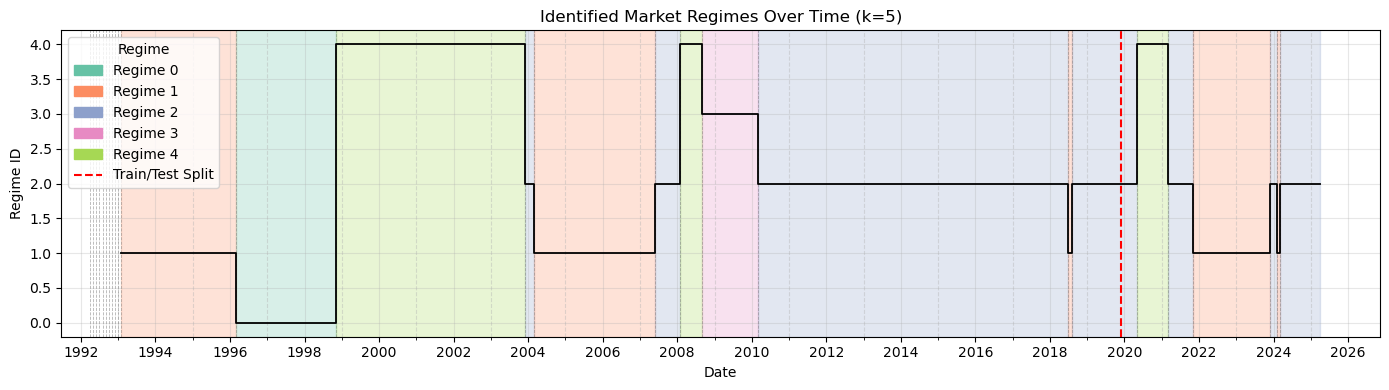

In [168]:
# --- Align with monthly data (forward fill to cover all months) ---
regime_monthly = regime_df.reindex(X_expanded.index, method="ffill")
X_with_regime = X_expanded.copy()
X_with_regime["Regime"] = regime_monthly["Regime"]

print("Merged successfully — regime counts:")
print(X_with_regime["Regime"].value_counts(dropna=False))

# --- Prepare for plotting ---
x = pd.to_datetime(X_with_regime.index)
vals = X_with_regime["Regime"].values
unique_regs = sorted(X_with_regime["Regime"].dropna().unique())
palette = sns.color_palette("Set2", n_colors=len(unique_regs))
colors = dict(zip(unique_regs, palette))

# --- Identify regime segments ---
seg_starts = [x[0]]
seg_labels = [vals[0]]
for i in range(1, len(vals)):
    if vals[i] != vals[i - 1]:
        seg_starts.append(x[i])
        seg_labels.append(vals[i])
seg_ends = seg_starts[1:] + [x[-1]]

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.step(x, vals, where="post", color="black", lw=1.3, zorder=3)

ymin, ymax = ax.get_ylim()
for s, e, lab in zip(seg_starts, seg_ends, seg_labels):
    if not np.isnan(lab):
        ax.axvspan(s, e, color=colors.get(lab, "grey"), alpha=0.25, zorder=1)

# --- Mark regime change boundaries ---
for s in seg_starts[1:]:
    ax.axvline(s, color="grey", lw=0.6, alpha=0.6, linestyle="--")

# --- Add train/test split line ---
ax.axvline(pd.Timestamp(train_end), color="red", linestyle="--", lw=1.5, label="Train/Test Split")

# --- Legend ---
handles = [mpatches.Patch(color=colors[r], label=f"Regime {int(r)}") for r in unique_regs]
# handles.append(mpatches.Patch(color="none", label="-- Train/Test Split"))
handles.append(
    plt.Line2D(
        [0], [0],
        color="red",
        lw=1.5,
        linestyle="--",
        label="Train/Test Split"
    )
)
ax.legend(handles=handles, title="Regime", loc="upper left")

# --- Titles & labels ---
ax.set_title(f"Identified Market Regimes Over Time (k={final_k})")
ax.set_xlabel("Date")
ax.set_ylabel("Regime ID")
ax.grid(alpha=0.3)

# --- Year grid setup ---
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.grid(True, which='minor', axis='x', linestyle='--', alpha=0.4)
ax.xaxis.set_major_locator(mdates.YearLocator(2))          # show every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()
plt.savefig('static_kmeans_regimes.png')

Full-sample regimes (head):
            Regime
Date              
1993-02-01       2
1993-03-01       2
1993-04-01       2
1993-05-01       2
1993-06-01       2

Merged successfully — full-sample regime counts:
Regime
2.0    238
0.0     75
1.0     53
NaN     11
4.0     11
3.0     10
Name: count, dtype: int64


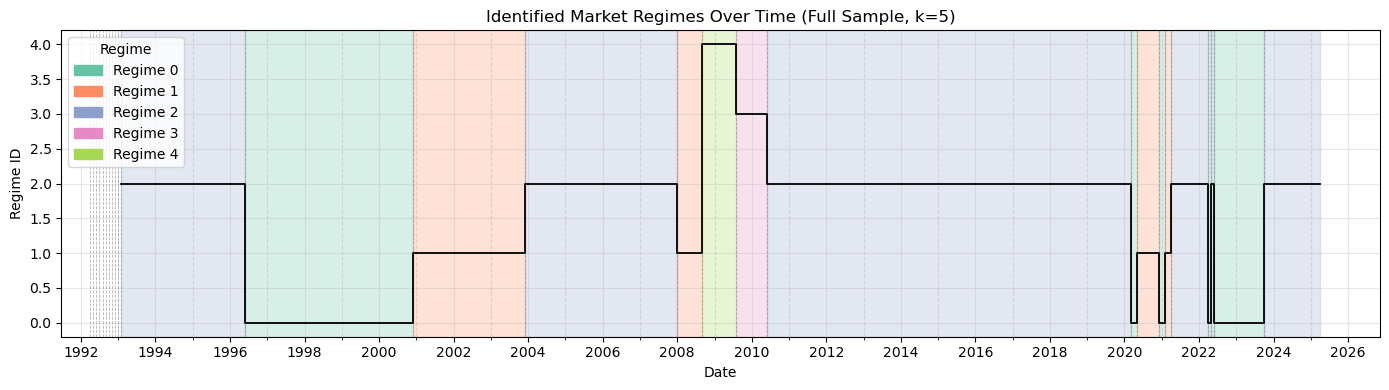

In [169]:
# ============================================
# Full-sample TSKMeans (no train/test split)
# ============================================

# 1) Fit model on ALL windows
full_model = TimeSeriesKMeans(
    n_clusters=final_k,
    metric="dtw",
    metric_params={"sakoe_chiba_radius": 1},
    n_init=3,
    max_iter=30,
    random_state=42
)

full_labels = full_model.fit_predict(Xw)   # <-- use all windows

# 2) Build full-sample regime dataframe (window-end index)
regime_full_df = pd.DataFrame(
    {"Regime": full_labels},
    index=idx_w_dt
).sort_index()

print("Full-sample regimes (head):")
print(regime_full_df.head())

# 3) Align with monthly feature index (forward-fill)
regime_full_monthly = regime_full_df.reindex(X_expanded.index, method="ffill")

X_with_regime_full = X_expanded.copy()
X_with_regime_full["Regime"] = regime_full_monthly["Regime"]

print("\nMerged successfully — full-sample regime counts:")
print(X_with_regime_full["Regime"].value_counts(dropna=False))

# 4) Prepare data for plotting
x_full   = pd.to_datetime(X_with_regime_full.index)
vals_full = X_with_regime_full["Regime"].values
unique_regs_full = sorted(X_with_regime_full["Regime"].dropna().unique())
palette_full = sns.color_palette("Set2", n_colors=len(unique_regs_full))
colors_full = dict(zip(unique_regs_full, palette_full))

# Identify contiguous regime segments
seg_starts = [x_full[0]]
seg_labels = [vals_full[0]]
for i in range(1, len(vals_full)):
    if vals_full[i] != vals_full[i - 1]:
        seg_starts.append(x_full[i])
        seg_labels.append(vals_full[i])
seg_ends = seg_starts[1:] + [x_full[-1]]

# 5) Plot full-sample regimes (no train/test split)
fig, ax = plt.subplots(figsize=(14, 4))

ax.step(x_full, vals_full, where="post", color="black", lw=1.3, zorder=3)

for s, e, lab in zip(seg_starts, seg_ends, seg_labels):
    if not np.isnan(lab):
        ax.axvspan(s, e, color=colors_full.get(lab, "grey"), alpha=0.25, zorder=1)

# Vertical lines at regime changes
for s in seg_starts[1:]:
    ax.axvline(s, color="grey", lw=0.6, alpha=0.6, linestyle="--")

# Legend (just regimes)
handles = [
    mpatches.Patch(color=colors_full[r], label=f"Regime {int(r)}")
    for r in unique_regs_full
]
ax.legend(handles=handles, title="Regime", loc="upper left")

# Titles & axes
ax.set_title(f"Identified Market Regimes Over Time (Full Sample, k={final_k})")
ax.set_xlabel("Date")
ax.set_ylabel("Regime ID")
ax.grid(alpha=0.3)

# Year grid
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.grid(True, which="minor", axis="x", linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

In [48]:
def summarize_core_regimes_separate(X_with_regime, split_date="2019-12"):
    """
    Summarize regimes using one key indicator per macro dimension.
    Display train and test summaries separately.
    """
    # --- Core features: one per macro pillar ---
    core_features = [
        "INDPRO",           # Growth
        "CUSR0000SAS",      # Inflation
        "USGG2YR Index",    # Policy / rates
        "LUACOAS Index",    # Credit spreads
        "VIX Index",        # Market volatility
        "CAPE"              # Valuation
    ]
    available = [f for f in core_features if f in X_with_regime.columns]

    df = X_with_regime.dropna(subset=["Regime"]).copy()
    df.index = pd.to_datetime(df.index)
    split = pd.Timestamp(split_date)

    # --- Split train / test ---
    train_df = df[df.index <= split]
    test_df  = df[df.index > split]

    print(f"Train period: {train_df.index.min().strftime('%Y-%m')} → {train_df.index.max().strftime('%Y-%m')} "
          f"({len(train_df):,} obs)")
    print(f"Test  period: {test_df.index.min().strftime('%Y-%m')} → {test_df.index.max().strftime('%Y-%m')} "
          f"({len(test_df):,} obs)\n")

    # --- Helper to compute mean ± std ---
    def regime_summary(df):
        g = df.groupby("Regime")[available]
        mean, std = g.mean().round(2), g.std().round(2)
        summary = mean.astype(str) + " ± " + std.astype(str)
        return summary, mean

    # --- Train summary ---
    train_summary_str, train_mean = regime_summary(train_df)
    print("=== TRAIN PERIOD SUMMARY (≤ Split) ===")
    display(train_summary_str)

    # --- Test summary ---
    test_summary_str, test_mean = regime_summary(test_df)
    print("\n=== TEST PERIOD SUMMARY (> Split) ===")
    display(test_summary_str)

    # --- Visualize side-by-side heatmaps for context ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    sns.heatmap(train_mean.T, cmap="RdYlGn", center=0, ax=axes[0], annot=True, fmt=".2f")
    axes[0].set_title("Train Data (≤ Split)")
    sns.heatmap(test_mean.T, cmap="RdYlGn", center=0, ax=axes[1], annot=True, fmt=".2f")
    axes[1].set_title("Test Data (> Split)")

    for ax in axes:
        ax.set_xlabel("Regime")
        ax.set_ylabel("Indicator")

    plt.suptitle("Core Macro & Market Indicators by Regime", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return train_summary_str, test_summary_str

Train period: 1993-02 → 2019-12 (323 obs)
Test  period: 2020-01 → 2025-04 (64 obs)

=== TRAIN PERIOD SUMMARY (≤ Split) ===


,INDPRO,CUSR0000SAS,USGG2YR Index,LUACOAS Index,VIX Index,CAPE
Regime,,,,,,
0.0,0.43 ± 1.0,0.01 ± 0.6,-0.03 ± 0.82,-0.64 ± 1.07,1.28 ± 1.13,0.19 ± 1.78
1.0,0.16 ± 0.99,0.02 ± 0.97,0.36 ± 0.88,-0.72 ± 0.41,-0.82 ± 0.37,0.05 ± 0.69
2.0,-0.09 ± 0.72,0.02 ± 0.65,0.03 ± 0.62,0.13 ± 0.54,-0.34 ± 0.69,0.04 ± 0.77
3.0,-1.01 ± 2.47,-0.03 ± 0.78,-0.18 ± 0.85,3.0 ± 2.41,1.94 ± 1.7,-0.09 ± 1.28
4.0,-0.47 ± 0.96,-0.0 ± 1.21,0.02 ± 1.05,1.93 ± 1.0,0.83 ± 0.72,-0.27 ± 1.46



=== TEST PERIOD SUMMARY (> Split) ===


,INDPRO,CUSR0000SAS,USGG2YR Index,LUACOAS Index,VIX Index,CAPE
Regime,,,,,,
1.0,0.01 ± 0.5,-0.06 ± 1.26,0.75 ± 1.47,-0.08 ± 0.24,0.19 ± 0.79,-0.29 ± 1.31
2.0,-0.72 ± 3.01,-0.06 ± 1.21,-0.28 ± 1.0,-0.42 ± 0.53,0.05 ± 1.2,-0.07 ± 1.55
4.0,1.04 ± 2.36,0.46 ± 1.75,0.07 ± 0.1,-0.13 ± 0.35,1.07 ± 0.66,0.92 ± 0.62


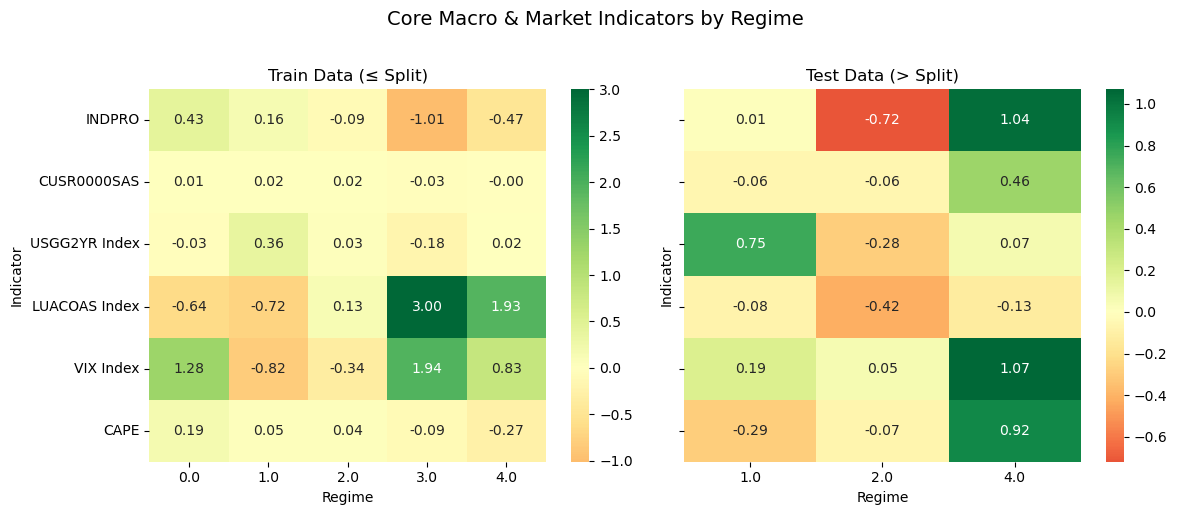

In [50]:
train_summary, test_summary = summarize_core_regimes_separate(X_with_regime, split_date="2019-12")

In [ ]:
def summarize_features_by_regime_simple(
    selected_features,
    regime_df,
    scale_col1=100,
    scale_col2=1000,
    tolerance_days=60,
    friendly_names=None,
):
    """
    Align features to regimes, scale first two columns, and return
    only the mean ± std table by regime (NO ANOVA, NO effect size).
    """

    # ------------------------------------------------------------
    # 0. Normalize regime_df format
    # ------------------------------------------------------------
    if isinstance(regime_df, pd.Series):
        regime_df = regime_df.to_frame("Regime")

    if "Regime" not in regime_df.columns:
        possible_cols = [c for c in regime_df.columns if c.lower() != "date"]
        if len(possible_cols) != 1:
            raise ValueError("regime_df must contain a single regime column.")
        regime_df = regime_df.rename(columns={possible_cols[0]: "Regime"})

    if not isinstance(regime_df.index, pd.DatetimeIndex):
        if "Date" in regime_df.columns:
            regime_df["Date"] = pd.to_datetime(regime_df["Date"])
            regime_df = regime_df.set_index("Date")
        else:
            regime_df.index = pd.to_datetime(regime_df.index)

    regime_df = regime_df.sort_index()

    # ------------------------------------------------------------
    # 1. merge_asof to align features with regime dates
    # ------------------------------------------------------------
    sf = selected_features.sort_index().copy()
    rg = regime_df.copy()

    sf = sf.reset_index().rename(columns={"index": "Date"})
    rg = rg.reset_index().rename(columns={"index": "Date"})
    sf["Date"] = pd.to_datetime(sf["Date"])

    merged = pd.merge_asof(
        sf,
        rg,
        on="Date",
        direction="nearest",
        tolerance=pd.Timedelta(f"{tolerance_days}D"),
    )

    merged = merged.dropna(subset=["Regime"])
    merged["Regime"] = merged["Regime"].astype(int)
    merged = merged.set_index("Date")

    feature_cols = selected_features.columns.tolist()

    # ------------------------------------------------------------
    # 2. Apply scaling to first two features
    # ------------------------------------------------------------
    scaled = merged.copy()
    scale_dict = {col: 1 for col in feature_cols}

    if len(feature_cols) >= 1:
        scaled[feature_cols[0]] *= scale_col1
        scale_dict[feature_cols[0]] = scale_col1

    if len(feature_cols) >= 2:
        scaled[feature_cols[1]] *= scale_col2
        scale_dict[feature_cols[1]] = scale_col2

    # ------------------------------------------------------------
    # 3. Compute mean and std
    # ------------------------------------------------------------
    mean_tbl = scaled.groupby("Regime")[feature_cols].mean()
    std_tbl  = scaled.groupby("Regime")[feature_cols].std()

    # ------------------------------------------------------------
    # 4. Rename columns using friendly names + scaling info
    # ------------------------------------------------------------
    if friendly_names is None:
        friendly_names = {}

    display_names = []
    for col in feature_cols:
        base = friendly_names.get(col, col)
        s = scale_dict[col]
        display_names.append(f"{base} (×{s})" if s != 1 else f"{base}")

    mean_tbl.columns = display_names
    std_tbl.columns  = display_names

    # ------------------------------------------------------------
    # 5. Build final "mean ± std" table
    # ------------------------------------------------------------
    summary_tbl = (
        mean_tbl.round(2).astype(str)
        + " ± "
        + std_tbl.round(2).astype(str)
    )

    summary_tbl.index.name = "Regime"

    return summary_tbl, mean_tbl, std_tbl

In [154]:
friendly_names = {
    "INDPRO": "Industrial Production (YoY)",
    "CUSR0000SAS": "Core CPI (MoM)",
    "USGG2YR Index": "2Y Treasury Yield Change",
    "LUACOAS Index": "US Financial Conditions",
    "VIX Index": "VIX Volatility",
    "CAPE": "CAPE Valuation",
    ".MARGINSP G Index": "Margin Debt Growth",
    "USURTOT Index": "Unemployment Rate",
    "SPX Index": "SPX Index Level",
}

summary_tbl, mean_tbl, std_tbl = summarize_features_by_regime_simple(
    selected_features=sf_df,
    regime_df=regime_train_df,
    scale_col1=100,
    scale_col2=1000,
    friendly_names=friendly_names
)

display(summary_tbl)

,Industrial Production (YoY) (×100),Core CPI (MoM) (×1000),2Y Treasury Yield Change,US Financial Conditions,VIX Volatility,CAPE Valuation,Margin Debt Growth,Unemployment Rate,SPX Index
Regime,,,,,,,,,
0,0.51 ± 0.51,-0.02 ± 0.87,-0.04 ± 0.25,0.68 ± 0.22,22.43 ± 6.72,0.24 ± 1.08,6.67 ± 0.34,4.98 ± 0.39,860.48 ± 165.49
1,0.29 ± 0.51,0.01 ± 1.51,0.05 ± 0.27,0.82 ± 0.11,13.24 ± 1.81,0.07 ± 0.5,6.66 ± 2.03,5.58 ± 0.82,895.64 ± 439.45
2,0.11 ± 0.47,0.03 ± 0.91,-0.02 ± 0.17,1.4 ± 0.34,17.31 ± 5.38,0.07 ± 0.72,10.15 ± 1.11,6.1 ± 1.99,1921.13 ± 589.3
3,-0.5 ± 1.58,-0.08 ± 1.17,-0.09 ± 0.25,3.57 ± 1.6,34.49 ± 11.94,-0.08 ± 1.27,7.03 ± 0.4,8.56 ± 1.42,981.86 ± 138.57
4,0.03 ± 0.51,-0.03 ± 1.77,-0.03 ± 0.31,1.65 ± 0.5,24.29 ± 4.51,-0.15 ± 1.35,6.96 ± 0.8,4.93 ± 0.82,1197.02 ± 193.22


In [155]:
regime_labels = {
    0: "Mid-Cycle Stable Growth",
    1: "Healthy Expansion",
    2: "Late-Cycle Softening",
    3: "Crisis / Shock",
    4: "Early-Cycle Recovery",
}
X_with_regime["Regime_Label"] = X_with_regime["Regime"].map(regime_labels)

In [162]:
# ============================================================
# 0. Daily prices → monthly returns
# ============================================================

# df_px: daily price DataFrame, either Date index or Date column
df_px = df_px.copy()

# Ensure datetime index
if "Date" in df_px.columns:
    df_px["Date"] = pd.to_datetime(df_px["Date"])
    df_px = df_px.set_index("Date")
else:
    df_px.index = pd.to_datetime(df_px.index)

df_px = df_px.sort_index()

# Use last available price each month (month-end)
px_m = df_px.resample("M").last()

# Monthly returns
df_ret = px_m.pct_change().dropna()

# Example: construct Agg Bond excess over short-term treasury
df_ret["US Agg Bond excess"] = df_ret["US Agg Bond"] - df_ret["US Short-term Treasury"]


# ============================================================
# 1. Prepare monthly index for regimes
# ============================================================
# X_with_regime should have "Regime" and "Regime_Label"
X_reg = X_with_regime[["Regime", "Regime_Label"]].copy()

# Force to month-end timestamps to align with df_ret
X_reg.index = pd.to_datetime(X_reg.index).to_period("M").to_timestamp("M")

# Also make sure df_ret index is month-end timestamps
df_ret.index = df_ret.index.to_period("M").to_timestamp("M")

# ============================================================
# 2. Align returns and regimes
# ============================================================
merged = df_ret.join(X_reg, how="inner")

# ============================================================
# 3. Compute 6M and 12M forward returns from monthly returns
# ============================================================

# For each asset column, rolling over monthly returns:
fwd_6m = df_ret.rolling(window=6).apply(lambda x: (1 + x).prod() - 1, raw=True).shift(-6)
fwd_12m = df_ret.rolling(window=12).apply(lambda x: (1 + x).prod() - 1, raw=True).shift(-12)

merged_6m = merged.join(fwd_6m.add_suffix(" (6M fwd)"))
merged_12m = merged.join(fwd_12m.add_suffix(" (12M fwd)"))

print(f"Aligned dataset shape (12M): {merged_12m.shape}")
print("Sample preview:")
display(merged_12m.head(3))


# ============================================================
# 4. Summary: mean ± std forward returns by regime
# ============================================================
def summary_table(df, suffix):
    cols = [c for c in df.columns if suffix in c]
    table = (
        df.groupby("Regime_Label")[cols]
        .agg(["mean", "std"])
        .round(3)
    )

    # flatten multiindex columns
    table.columns = [f"{col[0]}_{col[1]}" for col in table.columns]

    combined = pd.DataFrame(index=table.index)
    for c in cols:
        mean_col, std_col = f"{c}_mean", f"{c}_std"
        combined[c] = table[mean_col].astype(str) + " ± " + table[std_col].astype(str)
    
    return combined

summary_6m = summary_table(merged_6m, "(6M fwd)")
summary_12m = summary_table(merged_12m, "(12M fwd)")

print("=== 6-MONTH FORWARD RETURN SUMMARY BY REGIME ===")
display(summary_6m)

print("\n=== 12-MONTH FORWARD RETURN SUMMARY BY REGIME ===")
display(summary_12m)


# ============================================================
# 5. ANOVA: regime-level differences in forward 12M returns
# ============================================================
print("\n=== ANOVA Significance Tests (12M fwd) ===")

key_assets = [
    "Russell 1000",
    "MSCI EM Index (EM Equities)",
    "US Agg Bond excess",
    "Gold",
    "Dollar",
]

for asset in key_assets:
    col = asset + " (12M fwd)"
    if col not in merged_12m.columns:
        print(f"⚠️ {asset} not found — skipping.")
        continue
    
    # collect groups by regime label
    groups = [
        merged_12m.loc[merged_12m["Regime_Label"] == r, col].dropna()
        for r in merged_12m["Regime_Label"].dropna().unique()
    ]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) < 2:
        print(f"{asset}: insufficient data across regimes — skipped.")
        continue

    f, p = stats.f_oneway(*groups)
    print(f"{asset}: F={f:.2f}, p={p:.4f}")

Aligned dataset shape (12M): (398, 32)
Sample preview:


/var/folders/n6/pz2q030s2892kgbyw470z2nm0000gn/T/ipykernel_73996/3212292160.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  px_m = df_px.resample("M").last()


,Russell 1000,Russell 1000 Value,Russell 1000 Growth,MSCI World ex USA Index (DM ex-US Equities),MSCI EM Index (EM Equities),US Agg Bond,US Short-term Treasury,US Long-term Treasury,US IG Corporate Bond,US HY Corporate Bond,...,US Agg Bond (12M fwd),US Short-term Treasury (12M fwd),US Long-term Treasury (12M fwd),US IG Corporate Bond (12M fwd),US HY Corporate Bond (12M fwd),Global Agg ex-US Bond USD Hedged (12M fwd),Gold (12M fwd),Dollar (12M fwd),Russell 2000 (12M fwd),US Agg Bond excess (12M fwd)
Date,,,,,,,,,,,,,,,,,,,,,
1992-03-31,-0.023708,-0.017242,-0.029376,-0.066956,0.031580,-0.005638,-0.002350,-0.011043,-0.004286,0.012399,...,0.132902,0.106068,0.193913,0.150143,0.143273,0.085948,-0.011414,0.062022,0.130558,0.024598
1992-04-30,0.022538,0.040714,0.006358,0.002004,-0.011916,0.007223,0.009728,-0.000973,0.004987,0.003798,...,0.132610,0.103707,0.204231,0.153246,0.148884,0.083090,0.053367,0.049963,0.139543,0.026546
1992-05-31,0.002945,0.000893,0.004642,0.062503,-0.005928,0.018870,0.012248,0.027748,0.022338,0.014110,...,0.113049,0.086661,0.175563,0.129377,0.146359,0.078861,0.110370,0.060757,0.171043,0.024544


=== 6-MONTH FORWARD RETURN SUMMARY BY REGIME ===


,Russell 1000 (6M fwd),Russell 1000 Value (6M fwd),Russell 1000 Growth (6M fwd),MSCI World ex USA Index (DM ex-US Equities) (6M fwd),MSCI EM Index (EM Equities) (6M fwd),US Agg Bond (6M fwd),US Short-term Treasury (6M fwd),US Long-term Treasury (6M fwd),US IG Corporate Bond (6M fwd),US HY Corporate Bond (6M fwd),Global Agg ex-US Bond USD Hedged (6M fwd),Gold (6M fwd),Dollar (6M fwd),Russell 2000 (6M fwd),US Agg Bond excess (6M fwd)
Regime_Label,,,,,,,,,,,,,,,
Crisis / Shock,0.087 ± 0.166,0.074 ± 0.184,0.1 ± 0.153,0.09 ± 0.211,0.218 ± 0.256,0.045 ± 0.016,0.015 ± 0.013,0.024 ± 0.076,0.093 ± 0.052,0.181 ± 0.139,0.032 ± 0.011,0.118 ± 0.066,-0.012 ± 0.054,0.113 ± 0.193,0.03 ± 0.016
Early-Cycle Recovery,-0.002 ± 0.154,0.01 ± 0.149,-0.015 ± 0.183,-0.008 ± 0.176,0.026 ± 0.239,0.026 ± 0.03,0.025 ± 0.022,0.027 ± 0.072,0.023 ± 0.046,0.013 ± 0.096,0.022 ± 0.022,0.022 ± 0.086,0.006 ± 0.049,0.051 ± 0.199,0.001 ± 0.017
Healthy Expansion,0.051 ± 0.076,0.046 ± 0.068,0.056 ± 0.095,0.057 ± 0.087,0.084 ± 0.158,0.015 ± 0.041,0.016 ± 0.023,0.008 ± 0.086,0.017 ± 0.051,0.035 ± 0.046,0.023 ± 0.037,0.055 ± 0.093,0.007 ± 0.039,0.046 ± 0.085,-0.0 ± 0.021
Late-Cycle Softening,0.05 ± 0.081,0.031 ± 0.084,0.069 ± 0.091,0.012 ± 0.088,0.007 ± 0.107,0.018 ± 0.027,0.011 ± 0.018,0.036 ± 0.086,0.023 ± 0.036,0.03 ± 0.045,0.019 ± 0.021,0.05 ± 0.116,0.009 ± 0.04,0.033 ± 0.112,0.007 ± 0.015
Mid-Cycle Stable Growth,0.128 ± 0.09,0.109 ± 0.091,0.147 ± 0.099,0.039 ± 0.086,-0.059 ± 0.192,0.043 ± 0.02,0.035 ± 0.013,0.063 ± 0.05,0.045 ± 0.022,0.045 ± 0.04,0.06 ± 0.014,-0.054 ± 0.043,0.032 ± 0.038,0.045 ± 0.131,0.008 ± 0.009



=== 12-MONTH FORWARD RETURN SUMMARY BY REGIME ===


,Russell 1000 (12M fwd),Russell 1000 Value (12M fwd),Russell 1000 Growth (12M fwd),MSCI World ex USA Index (DM ex-US Equities) (12M fwd),MSCI EM Index (EM Equities) (12M fwd),US Agg Bond (12M fwd),US Short-term Treasury (12M fwd),US Long-term Treasury (12M fwd),US IG Corporate Bond (12M fwd),US HY Corporate Bond (12M fwd),Global Agg ex-US Bond USD Hedged (12M fwd),Gold (12M fwd),Dollar (12M fwd),Russell 2000 (12M fwd),US Agg Bond excess (12M fwd)
Regime_Label,,,,,,,,,,,,,,,
Crisis / Shock,0.198 ± 0.153,0.175 ± 0.165,0.222 ± 0.147,0.175 ± 0.18,0.392 ± 0.286,0.084 ± 0.023,0.031 ± 0.013,0.053 ± 0.077,0.169 ± 0.07,0.336 ± 0.176,0.055 ± 0.02,0.268 ± 0.085,-0.031 ± 0.041,0.26 ± 0.182,0.051 ± 0.022
Early-Cycle Recovery,0.005 ± 0.221,0.023 ± 0.205,-0.014 ± 0.268,0.002 ± 0.246,0.056 ± 0.308,0.059 ± 0.046,0.049 ± 0.037,0.062 ± 0.084,0.062 ± 0.057,0.051 ± 0.111,0.047 ± 0.034,0.066 ± 0.1,0.006 ± 0.06,0.082 ± 0.266,0.01 ± 0.016
Healthy Expansion,0.12 ± 0.119,0.1 ± 0.108,0.139 ± 0.146,0.109 ± 0.096,0.157 ± 0.212,0.039 ± 0.056,0.038 ± 0.037,0.03 ± 0.111,0.043 ± 0.065,0.076 ± 0.06,0.054 ± 0.055,0.133 ± 0.152,0.011 ± 0.054,0.093 ± 0.12,0.001 ± 0.025
Late-Cycle Softening,0.09 ± 0.142,0.057 ± 0.142,0.122 ± 0.161,0.008 ± 0.154,-0.001 ± 0.188,0.03 ± 0.046,0.019 ± 0.029,0.062 ± 0.133,0.038 ± 0.064,0.051 ± 0.087,0.036 ± 0.036,0.07 ± 0.171,0.025 ± 0.058,0.07 ± 0.185,0.011 ± 0.028
Mid-Cycle Stable Growth,0.253 ± 0.101,0.213 ± 0.12,0.292 ± 0.099,0.086 ± 0.085,-0.075 ± 0.283,0.077 ± 0.034,0.066 ± 0.018,0.106 ± 0.082,0.078 ± 0.039,0.077 ± 0.061,0.108 ± 0.03,-0.105 ± 0.059,0.061 ± 0.061,0.091 ± 0.178,0.01 ± 0.017



=== ANOVA Significance Tests (12M fwd) ===
Russell 1000: F=17.63, p=0.0000
MSCI EM Index (EM Equities): F=18.19, p=0.0000
US Agg Bond excess: F=17.27, p=0.0000
Gold: F=25.06, p=0.0000
Dollar: F=9.61, p=0.0000


In [163]:
# --- Load your data ---
df_ret["US Agg Bond excess"] = df_ret["US Agg Bond"] - df_ret["US Short-term Treasury"]

# --- 1) Prepare monthly index ---
df_ret = df_ret.copy()
df_ret.index = pd.to_datetime(df_ret.index)
df_ret.index = df_ret.index.to_period("M").to_timestamp()  # month-end timestamps

# --- 2) Prepare regime data ---
X_reg = X_with_regime[["Regime", "Regime_Label"]].copy()
X_reg.index = pd.to_datetime(X_reg.index).to_period("M").to_timestamp()

# --- 3) Align by date ---
merged = df_ret.join(X_reg, how="inner")

# --- 4) Compute forward 6m and 12m returns ---
fwd_6m = df_ret.rolling(window=6).apply(lambda x: (1 + x).prod() - 1, raw=True).shift(-6)
fwd_12m = df_ret.rolling(window=12).apply(lambda x: (1 + x).prod() - 1, raw=True).shift(-12)

merged_6m = merged.join(fwd_6m.add_suffix(" (6M fwd)"))
merged_12m = merged.join(fwd_12m.add_suffix(" (12M fwd)"))

print(f"Aligned dataset shape: {merged_12m.shape}")
print("Sample preview:")
display(merged_12m.head(3))

# --- 5) Summary: mean ± std forward returns by regime ---
def summary_table(df, suffix):
    cols = [c for c in df.columns if suffix in c]
    table = (
        df.groupby("Regime_Label")[cols]
        .agg(["mean", "std"])
        .round(3)
    )

    # flatten multiindex columns for readability
    table.columns = [f"{col[0]}_{col[1]}" for col in table.columns]

    # combine mean ± std into one formatted cell
    combined = pd.DataFrame(index=table.index)
    for c in cols:
        mean_col, std_col = f"{c}_mean", f"{c}_std"
        combined[c] = table[mean_col].astype(str) + " ± " + table[std_col].astype(str)
    
    return combined

summary_6m = summary_table(merged_6m, "(6M fwd)")
summary_12m = summary_table(merged_12m, "(12M fwd)")

print("=== 6-MONTH FORWARD RETURN SUMMARY ===")
display(summary_6m)
print("\n=== 12-MONTH FORWARD RETURN SUMMARY ===")
display(summary_12m)

# --- 6) ANOVA: regime-level differences in forward returns ---
print("\n=== ANOVA Significance Tests ===")
key_assets = ["Russell 1000", "MSCI EM Index (EM Equities)", "US Agg Bond excess", "Gold", "Dollar"]

for asset in key_assets:
    col = asset + " (12M fwd)"
    if col not in merged_12m.columns:
        print(f"⚠️ {asset} not found — skipping.")
        continue
    
    groups = [
        merged_12m.loc[merged_12m.Regime_Label == r, col].dropna()
        for r in merged_12m["Regime_Label"].dropna().unique()
    ]
    groups = [g for g in groups if len(g) > 0]
    
    if len(groups) < 2:
        print(f"{asset}: insufficient data across regimes — skipped.")
        continue

    f, p = stats.f_oneway(*groups)
    print(f"{asset}: F={f:.2f}, p={p:.4f}")

Aligned dataset shape: (398, 32)
Sample preview:


,Russell 1000,Russell 1000 Value,Russell 1000 Growth,MSCI World ex USA Index (DM ex-US Equities),MSCI EM Index (EM Equities),US Agg Bond,US Short-term Treasury,US Long-term Treasury,US IG Corporate Bond,US HY Corporate Bond,...,US Agg Bond (12M fwd),US Short-term Treasury (12M fwd),US Long-term Treasury (12M fwd),US IG Corporate Bond (12M fwd),US HY Corporate Bond (12M fwd),Global Agg ex-US Bond USD Hedged (12M fwd),Gold (12M fwd),Dollar (12M fwd),Russell 2000 (12M fwd),US Agg Bond excess (12M fwd)
Date,,,,,,,,,,,,,,,,,,,,,
1992-03-01,-0.023708,-0.017242,-0.029376,-0.066956,0.031580,-0.005638,-0.002350,-0.011043,-0.004286,0.012399,...,0.132902,0.106068,0.193913,0.150143,0.143273,0.085948,-0.011414,0.062022,0.130558,0.024598
1992-04-01,0.022538,0.040714,0.006358,0.002004,-0.011916,0.007223,0.009728,-0.000973,0.004987,0.003798,...,0.132610,0.103707,0.204231,0.153246,0.148884,0.083090,0.053367,0.049963,0.139543,0.026546
1992-05-01,0.002945,0.000893,0.004642,0.062503,-0.005928,0.018870,0.012248,0.027748,0.022338,0.014110,...,0.113049,0.086661,0.175563,0.129377,0.146359,0.078861,0.110370,0.060757,0.171043,0.024544


=== 6-MONTH FORWARD RETURN SUMMARY ===


,Russell 1000 (6M fwd),Russell 1000 Value (6M fwd),Russell 1000 Growth (6M fwd),MSCI World ex USA Index (DM ex-US Equities) (6M fwd),MSCI EM Index (EM Equities) (6M fwd),US Agg Bond (6M fwd),US Short-term Treasury (6M fwd),US Long-term Treasury (6M fwd),US IG Corporate Bond (6M fwd),US HY Corporate Bond (6M fwd),Global Agg ex-US Bond USD Hedged (6M fwd),Gold (6M fwd),Dollar (6M fwd),Russell 2000 (6M fwd),US Agg Bond excess (6M fwd)
Regime_Label,,,,,,,,,,,,,,,
Crisis / Shock,0.087 ± 0.166,0.074 ± 0.184,0.1 ± 0.153,0.09 ± 0.211,0.218 ± 0.256,0.045 ± 0.016,0.015 ± 0.013,0.024 ± 0.076,0.093 ± 0.052,0.181 ± 0.139,0.032 ± 0.011,0.118 ± 0.066,-0.012 ± 0.054,0.113 ± 0.193,0.03 ± 0.016
Early-Cycle Recovery,-0.002 ± 0.154,0.01 ± 0.149,-0.015 ± 0.183,-0.008 ± 0.176,0.026 ± 0.239,0.026 ± 0.03,0.025 ± 0.022,0.027 ± 0.072,0.023 ± 0.046,0.013 ± 0.096,0.022 ± 0.022,0.022 ± 0.086,0.006 ± 0.049,0.051 ± 0.199,0.001 ± 0.017
Healthy Expansion,0.051 ± 0.076,0.046 ± 0.068,0.056 ± 0.095,0.057 ± 0.087,0.084 ± 0.158,0.015 ± 0.041,0.016 ± 0.023,0.008 ± 0.086,0.017 ± 0.051,0.035 ± 0.046,0.023 ± 0.037,0.055 ± 0.093,0.007 ± 0.039,0.046 ± 0.085,-0.0 ± 0.021
Late-Cycle Softening,0.05 ± 0.081,0.031 ± 0.084,0.069 ± 0.091,0.012 ± 0.088,0.007 ± 0.107,0.018 ± 0.027,0.011 ± 0.018,0.036 ± 0.086,0.023 ± 0.036,0.03 ± 0.045,0.019 ± 0.021,0.05 ± 0.116,0.009 ± 0.04,0.033 ± 0.112,0.007 ± 0.015
Mid-Cycle Stable Growth,0.128 ± 0.09,0.109 ± 0.091,0.147 ± 0.099,0.039 ± 0.086,-0.059 ± 0.192,0.043 ± 0.02,0.035 ± 0.013,0.063 ± 0.05,0.045 ± 0.022,0.045 ± 0.04,0.06 ± 0.014,-0.054 ± 0.043,0.032 ± 0.038,0.045 ± 0.131,0.008 ± 0.009



=== 12-MONTH FORWARD RETURN SUMMARY ===


,Russell 1000 (12M fwd),Russell 1000 Value (12M fwd),Russell 1000 Growth (12M fwd),MSCI World ex USA Index (DM ex-US Equities) (12M fwd),MSCI EM Index (EM Equities) (12M fwd),US Agg Bond (12M fwd),US Short-term Treasury (12M fwd),US Long-term Treasury (12M fwd),US IG Corporate Bond (12M fwd),US HY Corporate Bond (12M fwd),Global Agg ex-US Bond USD Hedged (12M fwd),Gold (12M fwd),Dollar (12M fwd),Russell 2000 (12M fwd),US Agg Bond excess (12M fwd)
Regime_Label,,,,,,,,,,,,,,,
Crisis / Shock,0.198 ± 0.153,0.175 ± 0.165,0.222 ± 0.147,0.175 ± 0.18,0.392 ± 0.286,0.084 ± 0.023,0.031 ± 0.013,0.053 ± 0.077,0.169 ± 0.07,0.336 ± 0.176,0.055 ± 0.02,0.268 ± 0.085,-0.031 ± 0.041,0.26 ± 0.182,0.051 ± 0.022
Early-Cycle Recovery,0.005 ± 0.221,0.023 ± 0.205,-0.014 ± 0.268,0.002 ± 0.246,0.056 ± 0.308,0.059 ± 0.046,0.049 ± 0.037,0.062 ± 0.084,0.062 ± 0.057,0.051 ± 0.111,0.047 ± 0.034,0.066 ± 0.1,0.006 ± 0.06,0.082 ± 0.266,0.01 ± 0.016
Healthy Expansion,0.12 ± 0.119,0.1 ± 0.108,0.139 ± 0.146,0.109 ± 0.096,0.157 ± 0.212,0.039 ± 0.056,0.038 ± 0.037,0.03 ± 0.111,0.043 ± 0.065,0.076 ± 0.06,0.054 ± 0.055,0.133 ± 0.152,0.011 ± 0.054,0.093 ± 0.12,0.001 ± 0.025
Late-Cycle Softening,0.09 ± 0.142,0.057 ± 0.142,0.122 ± 0.161,0.008 ± 0.154,-0.001 ± 0.188,0.03 ± 0.046,0.019 ± 0.029,0.062 ± 0.133,0.038 ± 0.064,0.051 ± 0.087,0.036 ± 0.036,0.07 ± 0.171,0.025 ± 0.058,0.07 ± 0.185,0.011 ± 0.028
Mid-Cycle Stable Growth,0.253 ± 0.101,0.213 ± 0.12,0.292 ± 0.099,0.086 ± 0.085,-0.075 ± 0.283,0.077 ± 0.034,0.066 ± 0.018,0.106 ± 0.082,0.078 ± 0.039,0.077 ± 0.061,0.108 ± 0.03,-0.105 ± 0.059,0.061 ± 0.061,0.091 ± 0.178,0.01 ± 0.017



=== ANOVA Significance Tests ===
Russell 1000: F=17.63, p=0.0000
MSCI EM Index (EM Equities): F=18.19, p=0.0000
US Agg Bond excess: F=17.27, p=0.0000
Gold: F=25.06, p=0.0000
Dollar: F=9.61, p=0.0000


In [164]:
# --- Parameters ---
train_end = "2019-12"
key_assets = ["Russell 1000", "US Agg Bond", "Gold", "Dollar"]
fwd_cols = [a + " (6M fwd)" for a in key_assets]

# --- Split dataset ---
train_df = merged_6m.loc[merged_6m.index <= pd.Timestamp(train_end)]
test_df  = merged_6m.loc[merged_6m.index >  pd.Timestamp(train_end)]

# --- Helper to compute summary table with ANOVA ---
def forward_return_summary(df, key_assets):
    results = []
    for regime, g in df.groupby(["Regime", "Regime_Label"]):
        row = {"Regime": regime[0], "Regime_Label": regime[1]}
        for asset in key_assets:
            col = asset + " (6M fwd)"
            if col in g.columns:
                mean, std = g[col].mean(), g[col].std()
                row[col] = f"{mean:.3f} ± {std:.3f}"
        results.append(row)
    summary = pd.DataFrame(results)

    # --- ANOVA row ---
    pvals = {"Regime": "", "Regime_Label": "ANOVA p-value"}
    for asset in key_assets:
        col = asset + " (6M fwd)"
        groups = [
            df.loc[df["Regime_Label"] == r, col].dropna()
            for r in df["Regime_Label"].dropna().unique()
        ]
        groups = [g for g in groups if len(g) > 1]
        if len(groups) > 1:
            _, p = stats.f_oneway(*groups)
            pvals[col] = f"{p:.4f}"
        else:
            pvals[col] = "—"
    summary = pd.concat([summary, pd.DataFrame([pvals])], ignore_index=True)
    return summary

# --- Compute summaries ---
train_summary = forward_return_summary(train_df, key_assets)
test_summary  = forward_return_summary(test_df,  key_assets)

# --- Display ---
print("=== TRAIN SAMPLE — 6-MONTH FORWARD RETURNS BY REGIME ===")
display(
    train_summary.style
        .set_caption("Forward 6M Asset Returns by Market Regime (Train Sample, with ANOVA significance)")
)

print("\n=== TEST SAMPLE — 6-MONTH FORWARD RETURNS BY REGIME ===")
display(
    test_summary.style
        .set_caption("Forward 6M Asset Returns by Market Regime (Test Sample, with ANOVA significance)")
)

=== TRAIN SAMPLE — 6-MONTH FORWARD RETURNS BY REGIME ===


,Regime,Regime_Label,Russell 1000 (6M fwd),US Agg Bond (6M fwd),Gold (6M fwd),Dollar (6M fwd)
0,0.000000,Mid-Cycle Stable Growth,0.128 ± 0.090,0.043 ± 0.020,-0.054 ± 0.043,0.032 ± 0.038
1,1.000000,Healthy Expansion,0.056 ± 0.057,0.024 ± 0.032,0.057 ± 0.090,0.006 ± 0.039
2,2.000000,Late-Cycle Softening,0.045 ± 0.079,0.020 ± 0.025,0.033 ± 0.114,0.010 ± 0.040
3,3.000000,Crisis / Shock,0.087 ± 0.166,0.045 ± 0.016,0.118 ± 0.066,-0.012 ± 0.054
4,4.000000,Early-Cycle Recovery,-0.030 ± 0.145,0.031 ± 0.029,0.028 ± 0.086,0.012 ± 0.049
5,,ANOVA p-value,0.0000,0.0000,0.0000,0.0062



=== TEST SAMPLE — 6-MONTH FORWARD RETURNS BY REGIME ===


,Regime,Regime_Label,Russell 1000 (6M fwd),US Agg Bond (6M fwd),Gold (6M fwd),Dollar (6M fwd)
0,1.000000,Healthy Expansion,0.036 ± 0.116,-0.011 ± 0.052,0.049 ± 0.101,0.012 ± 0.039
1,2.000000,Late-Cycle Softening,0.076 ± 0.087,0.011 ± 0.035,0.133 ± 0.083,0.004 ± 0.040
2,4.000000,Early-Cycle Recovery,0.185 ± 0.051,-0.006 ± 0.016,-0.021 ± 0.069,-0.030 ± 0.029
3,,ANOVA p-value,0.0005,0.1428,0.0000,0.0144


In [165]:
# --- Parameters ---
train_end = "2019-12"
key_assets = ["Russell 1000", "US Agg Bond", "Gold", "Dollar"]
fwd_cols = [a + " (12M fwd)" for a in key_assets]

# --- Split dataset ---
train_df = merged_12m.loc[merged_12m.index <= pd.Timestamp(train_end)]
test_df  = merged_12m.loc[merged_12m.index >  pd.Timestamp(train_end)]

# --- Helper to compute summary table with ANOVA ---
def forward_return_summary(df, key_assets):
    results = []
    for regime, g in df.groupby(["Regime", "Regime_Label"]):
        row = {"Regime": regime[0], "Regime_Label": regime[1]}
        for asset in key_assets:
            col = asset + " (12M fwd)"
            if col in g.columns:
                mean, std = g[col].mean(), g[col].std()
                row[col] = f"{mean:.3f} ± {std:.3f}"
        results.append(row)
    summary = pd.DataFrame(results)

    # --- ANOVA row ---
    pvals = {"Regime": "", "Regime_Label": "ANOVA p-value"}
    for asset in key_assets:
        col = asset + " (12M fwd)"
        groups = [
            df.loc[df["Regime_Label"] == r, col].dropna()
            for r in df["Regime_Label"].dropna().unique()
        ]
        groups = [g for g in groups if len(g) > 1]
        if len(groups) > 1:
            _, p = stats.f_oneway(*groups)
            pvals[col] = f"{p:.4f}"
        else:
            pvals[col] = "—"
    summary = pd.concat([summary, pd.DataFrame([pvals])], ignore_index=True)
    return summary

# --- Compute summaries ---
train_summary = forward_return_summary(train_df, key_assets)
test_summary  = forward_return_summary(test_df,  key_assets)

# --- Display ---
print("=== TRAIN SAMPLE — 12-MONTH FORWARD RETURNS BY REGIME ===")
display(
    train_summary.style
        .set_caption("Forward 12M Asset Returns by Market Regime (Train Sample, with ANOVA significance)")
)

print("\n=== TEST SAMPLE — 12-MONTH FORWARD RETURNS BY REGIME ===")
display(
    test_summary.style
        .set_caption("Forward 12M Asset Returns by Market Regime (Test Sample, with ANOVA significance)")
)

=== TRAIN SAMPLE — 12-MONTH FORWARD RETURNS BY REGIME ===


,Regime,Regime_Label,Russell 1000 (12M fwd),US Agg Bond (12M fwd),Gold (12M fwd),Dollar (12M fwd)
0,0.000000,Mid-Cycle Stable Growth,0.253 ± 0.101,0.077 ± 0.034,-0.105 ± 0.059,0.061 ± 0.061
1,1.000000,Healthy Expansion,0.115 ± 0.104,0.051 ± 0.047,0.126 ± 0.161,0.010 ± 0.060
2,2.000000,Late-Cycle Softening,0.088 ± 0.131,0.038 ± 0.034,0.053 ± 0.162,0.025 ± 0.058
3,3.000000,Crisis / Shock,0.198 ± 0.153,0.084 ± 0.023,0.268 ± 0.085,-0.031 ± 0.041
4,4.000000,Early-Cycle Recovery,-0.038 ± 0.200,0.069 ± 0.040,0.077 ± 0.099,0.010 ± 0.061
5,,ANOVA p-value,0.0000,0.0000,0.0000,0.0000



=== TEST SAMPLE — 12-MONTH FORWARD RETURNS BY REGIME ===


,Regime,Regime_Label,Russell 1000 (12M fwd),US Agg Bond (12M fwd),Gold (12M fwd),Dollar (12M fwd)
0,1.000000,Healthy Expansion,0.135 ± 0.157,0.003 ± 0.063,0.152 ± 0.124,0.016 ± 0.030
1,2.000000,Late-Cycle Softening,0.105 ± 0.202,-0.019 ± 0.073,0.177 ± 0.186,0.025 ± 0.062
2,4.000000,Early-Cycle Recovery,0.299 ± 0.100,-0.011 ± 0.010,-0.014 ± 0.067,-0.019 ± 0.042
3,,ANOVA p-value,0.0121,0.4918,0.0031,0.0523


In [167]:
# --- 1) Define relative asset pairs ---
relative_pairs = {
    "Growth - Value": ("Russell 1000 Growth", "Russell 1000 Value"),
    "HY - IG": ("US HY Corporate Bond", "US IG Corporate Bond"),
    "Long - Short Treasury": ("US Long-term Treasury", "US Short-term Treasury"),
    "EM - DM Equities": ("MSCI EM Index (EM Equities)", "MSCI World ex USA Index (DM ex-US Equities)")
}

# --- 2) Compute forward 6-month returns from monthly returns ---
# df_ret is your monthly return DataFrame
fwd_6m = df_ret.rolling(window=6).apply(lambda x: (1 + x).prod() - 1, raw=True).shift(-6)
fwd_6m = fwd_6m.add_suffix(" (6M fwd)")

# --- 3) Merge with regime labels ---
reg = X_with_regime[["Regime", "Regime_Label"]].copy()
reg.index = pd.to_datetime(reg.index).to_period("M").to_timestamp()
merged = reg.join(fwd_6m, how="left")

# --- 4) Compute relative-performance spreads (6M forward) ---
rel_df = pd.DataFrame(index=merged.index)
for name, (a1, a2) in relative_pairs.items():
    col1, col2 = a1 + " (6M fwd)", a2 + " (6M fwd)"
    if col1 in merged.columns and col2 in merged.columns:
        # a1 outperformance vs a2
        rel_df[name + " (6M fwd)"] = merged[col1] - merged[col2]
    else:
        print(f"⚠️ Missing data for {name} — skipping.")

rel_df = rel_df.join(reg)

# --- 5) Split Train / Test ---
train_end = "2019-12"
train_df = rel_df.loc[rel_df.index <= pd.Timestamp(train_end)]
test_df  = rel_df.loc[rel_df.index >  pd.Timestamp(train_end)]

# --- Helper: build “mean ± std + ANOVA” summary ---
def relative_summary(df):
    cols = [c for c in df.columns if "fwd" in c]
    # per-regime stats
    summary = (
        df.groupby(["Regime", "Regime_Label"])[cols]
        .agg(["mean", "std"])
        .round(3)
    )
    summary.columns = [f"{col[0]}_{col[1]}" for col in summary.columns]

    combined = pd.DataFrame(index=summary.index)
    for col in [c for c in summary.columns if c.endswith("_mean")]:
        base = col.replace("_mean", "")
        combined[base] = summary[col].astype(str) + " ± " + summary[base + "_std"].astype(str)

    combined = combined.reset_index()

    # ANOVA row
    anova_pvals = {}
    for rel in cols:
        groups = [df.loc[df["Regime_Label"] == r, rel].dropna()
                  for r in df["Regime_Label"].dropna().unique()]
        groups = [g for g in groups if len(g) > 1]
        if len(groups) > 1:
            _, p = stats.f_oneway(*groups)
            anova_pvals[rel] = p
        else:
            anova_pvals[rel] = np.nan

    pval_row = {"Regime": "", "Regime_Label": "ANOVA p-value"}
    for rel, p in anova_pvals.items():
        pval_row[rel] = f"{p:.4f}" if not np.isnan(p) else "—"

    combined = pd.concat([combined, pd.DataFrame([pval_row])], ignore_index=True)
    return combined

# --- 6) Build tables ---
train_rel_summary = relative_summary(train_df)
test_rel_summary  = relative_summary(test_df)

# --- 7) Display ---
print("=== TRAIN SAMPLE — 6-MONTH FORWARD RELATIVE PERFORMANCE BY REGIME ===")
display(
    train_rel_summary.style
        .set_caption("Forward 6M Relative Performance by Market Regime (Train Sample)")
)

print("\n=== TEST SAMPLE — 6-MONTH FORWARD RELATIVE PERFORMANCE BY REGIME ===")
display(
    test_rel_summary.style
        .set_caption("Forward 6M Relative Performance by Market Regime (Test Sample)")
)

=== TRAIN SAMPLE — 6-MONTH FORWARD RELATIVE PERFORMANCE BY REGIME ===


,Regime,Regime_Label,Growth - Value (6M fwd),HY - IG (6M fwd),Long - Short Treasury (6M fwd),EM - DM Equities (6M fwd)
0,0.000000,Mid-Cycle Stable Growth,0.037 ± 0.06,-0.001 ± 0.041,0.027 ± 0.039,-0.098 ± 0.145
1,1.000000,Healthy Expansion,0.001 ± 0.045,0.017 ± 0.026,0.011 ± 0.051,0.051 ± 0.127
2,2.000000,Late-Cycle Softening,0.03 ± 0.053,0.005 ± 0.043,0.032 ± 0.078,-0.005 ± 0.061
3,3.000000,Crisis / Shock,0.026 ± 0.063,0.088 ± 0.1,0.01 ± 0.065,0.129 ± 0.089
4,4.000000,Early-Cycle Recovery,-0.024 ± 0.134,-0.02 ± 0.081,0.012 ± 0.046,0.038 ± 0.112
5,,ANOVA p-value,0.0000,0.0000,0.0878,0.0000



=== TEST SAMPLE — 6-MONTH FORWARD RELATIVE PERFORMANCE BY REGIME ===


,Regime,Regime_Label,Growth - Value (6M fwd),HY - IG (6M fwd),Long - Short Treasury (6M fwd),EM - DM Equities (6M fwd)
0,1.000000,Healthy Expansion,0.033 ± 0.11,0.023 ± 0.02,-0.06 ± 0.08,-0.04 ± 0.039
1,2.000000,Late-Cycle Softening,0.078 ± 0.107,0.017 ± 0.022,-0.008 ± 0.059,-0.003 ± 0.061
2,4.000000,Early-Cycle Recovery,-0.033 ± 0.09,0.056 ± 0.026,-0.069 ± 0.063,0.003 ± 0.087
3,,ANOVA p-value,0.0205,0.0000,0.0108,0.0380


In [306]:
df_ret = pd.read_csv("df_1M_ret.csv")
russel = pd.read_csv("Russel2000data.csv")

In [307]:
# ============================================================
# 0. Build monthly return panel from df_1M_ret.csv + Russel2000data.csv
# ============================================================
df_ret = df_ret.copy()

# --- 0.1: Parse df_ret into month-end indexed returns ---
# Detect date column (prefer "Date" if present)
if "Date" in df_ret.columns:
    date_col_ret = "Date"
else:
    # fallback: assume first column is date-like
    date_col_ret = df_ret.columns[0]

df_ret[date_col_ret] = pd.to_datetime(df_ret[date_col_ret])
# Force to month-end index (same convention as other code)
df_ret["Date"] = df_ret[date_col_ret] + pd.offsets.MonthEnd(0)
df_ret = df_ret.set_index("Date").sort_index()

# Keep only numeric columns as return series
ret_core = df_ret.select_dtypes(include=["number"])

# --- 0.2: Parse Russell 2000 price data and convert to monthly returns ---
russel = russel.copy()

# Detect date column
if "Date" in russel.columns:
    date_col_r = "Date"
else:
    date_col_r = russel.columns[0]

russel[date_col_r] = pd.to_datetime(russel[date_col_r])
russel = russel.sort_values(by=date_col_r)

# Detect price column: prefer "Adj Close" if present, else last non-date column
price_candidates = [c for c in russel.columns if c != date_col_r]
if "Adj Close" in russel.columns:
    price_col_r = "Adj Close"
elif price_candidates:
    price_col_r = price_candidates[-1]
else:
    raise ValueError("No price column found in Russel2000data.csv.")

# Compute simple returns
russel["Ret"] = russel[price_col_r].pct_change()

# Aggregate to month-end
russel["MonthEnd"] = russel[date_col_r].dt.to_period("M").dt.to_timestamp("M")
r2000_m = russel.groupby("MonthEnd")["Ret"].last().dropna()
r2000_m.name = "Russell 2000"

# --- 0.3: Join Russell 2000 monthly returns into the main panel ---
ret_all = ret_core.join(r2000_m, how="inner")

# ============================================================
# 1. Define benchmark universe & extract consistent monthly returns
# ============================================================
bench_w = {
    "Russell 1000 Value":      0.25,
    "Russell 1000 Growth":     0.25,
    "Russell 2000":            0.10,
    "US Short-term Treasury":  0.10,
    "US Long-term Treasury":   0.10,
    "US IG Corporate Bond":    0.15,
    "US HY Corporate Bond":    0.05,
}
alloc_cols = list(bench_w.keys())

# Make sure all required assets are present
missing = [c for c in alloc_cols if c not in ret_all.columns]
if missing:
    raise ValueError(f"Missing benchmark assets in combined returns: {missing}")

# Final monthly return matrix before regime alignment
ret_m = ret_all[alloc_cols].dropna().copy()

# ============================================================
# 2. Align regimes to month-end and build true vs tradable timelines
# ============================================================
regime_df = regime_df.copy()

# Ensure datetime index
if not isinstance(regime_df.index, pd.DatetimeIndex):
    regime_df.index = pd.to_datetime(regime_df.index)
regime_df = regime_df.sort_index()

# Force regimes to month-end (if they came from window-end dates)
regime_df = regime_df.resample("M").last().dropna()

# Build true vs tradable regime labels
regime_df["Regime_true"]   = regime_df["Regime"]
regime_df["Regime_signal"] = regime_df["Regime"].shift(1)

# Merge regimes onto monthly return index
df_regime = regime_df.reindex(ret_m.index)[["Regime_true", "Regime_signal"]]
# ------------------------------------------------------------
# Extend tradable regime one extra month past last regime date
# ------------------------------------------------------------
last_reg_true_date = regime_df.index.max()          # e.g., 2025-04-30
last_regime_val    = regime_df.loc[last_reg_true_date, "Regime"]

# One extra month-end after the last regime
extra_month = last_reg_true_date + pd.offsets.MonthEnd(1)   # 2025-05-31

# If we have returns for that extra month, assign April's regime as its signal
if extra_month in df_regime.index:
    df_regime.loc[extra_month, "Regime_signal"] = last_regime_val


# ============================================================
# 3. Truncate to period where tradable regime exists
# ============================================================
valid_mask = ~df_regime["Regime_signal"].isna()
common_idx = df_regime.index[valid_mask]

ret_m     = ret_m.loc[common_idx]
df_regime = df_regime.loc[common_idx]

# ============================================================
# 4. Build synthetic price index and forward 6M returns (monthly)
# ============================================================
px_m = (1.0 + ret_m).cumprod()

# 6-step ahead monthly returns: P_{t+6}/P_t - 1
fwd6m = px_m.shift(-6) / px_m - 1.0
fwd6m = fwd6m.dropna(how="all")

# ============================================================
# 5. Benchmark groups and helper
# ============================================================
groups = {
    "Equity": ["Russell 1000 Value", "Russell 1000 Growth", "Russell 2000"],
    "Rates":  ["US Short-term Treasury", "US Long-term Treasury"],
    "Credit": ["US IG Corporate Bond", "US HY Corporate Bond"],
}
bench = pd.Series(bench_w)

def group_totals(w):
    return pd.Series({
        "Equity": w[groups["Equity"]].sum(),
        "Rates":  w[groups["Rates"]].sum(),
        "Credit": w[groups["Credit"]].sum(),
    })

# ============================================================
# 6. Function: regime-conditional means using past only
# ============================================================
def past_regime_stats(decision_date):
    """
    Use only past samples whose forward 6-month return windows
    end before decision_date (in monthly space).
    """
    decision_date = pd.Timestamp(decision_date)

    # restrict forward samples to windows that end strictly before decision_date
    valid_idx = fwd6m.index < decision_date

    # regime signal aligned with fwd6m index
    reg_series = df_regime.reindex(fwd6m.index)["Regime_signal"]

    df_tmp = fwd6m.loc[valid_idx].copy()
    df_tmp["regime"] = reg_series.loc[valid_idx].values
    df_tmp = df_tmp.dropna(subset=["regime"])

    means = df_tmp.groupby("regime")[alloc_cols].mean()
    counts = df_tmp.groupby("regime")[alloc_cols].count()
    return means, counts

def shrink_table(means, counts, ridge=0.02):
    # grand mean across all regimes/assets
    gmean = means.stack().mean()
    # shrinkage weight by regime/asset
    w = counts / (counts + ridge * counts.stack().mean())
    return w * means + (1 - w) * gmean

# ============================================================
# 7. Constrained optimizer in MONTHLY space
# ============================================================
def target_from_signals(mu):
    sig = pd.Series(0.0, index=alloc_cols)

    # Standardize signals within each group
    for g, names in groups.items():
        m = mu[names].dropna()
        if len(m) >= 2:
            z = (m - m.mean()) / (m.std(ddof=0) + 1e-8)
            sig.loc[m.index] = z

    # Map standardized signals to target tilts around the benchmark
    w_des = bench + 0.05 * sig / (sig.abs().sum() + 1e-8)

    n = len(alloc_cols)
    w = cp.Variable(n)
    Aeq = np.ones((1, n))
    beq = np.array([1.0])
    constraints = [w >= 0, Aeq @ w == beq]

    # ±5% per asset
    for i, name in enumerate(alloc_cols):
        constraints += [
            w[i] >= bench[name] - 0.05,
            w[i] <= bench[name] + 0.05,
        ]

    # ±10% per group
    for g, names in groups.items():
        idx = [alloc_cols.index(nm) for nm in names]
        constraints += [
            cp.sum(w[idx]) >= group_totals(bench)[g] - 0.10,
            cp.sum(w[idx]) <= group_totals(bench)[g] + 0.10,
        ]

    obj = cp.Minimize(cp.sum_squares(w - w_des.values))
    cp.Problem(obj, constraints).solve(solver=cp.ECOS, verbose=False)
    w_opt = np.maximum(0, w.value)
    return pd.Series(w_opt / w_opt.sum(), index=alloc_cols)

# ============================================================
# 8. Monthly rebalancing loop (MONTHLY space)
#    Each month: one decision, one period return.
# ============================================================
month_starts = ret_m.index   # month-end dates
weights_m = {}

for m_start in month_starts:
    reg = df_regime.loc[m_start, "Regime_signal"]
    means, counts = past_regime_stats(m_start)

    # If we don't have enough history for this regime, stay at benchmark
    if (pd.isna(reg)) or (reg not in means.index):
        weights_m[m_start] = bench.copy()
        continue

    mu_reg = shrink_table(means, counts).loc[reg].reindex(alloc_cols)
    w_t = target_from_signals(mu_reg.fillna(0))
    weights_m[m_start] = w_t

w_m = pd.DataFrame(weights_m).T.sort_index()

# ============================================================
# 9. Monthly portfolio and benchmark returns
# ============================================================
# Strategy portfolio monthly return (weights at t applied to return over period ending at t)
port_r_m = (w_m * ret_m[alloc_cols]).sum(axis=1)

# Benchmark: static monthly rebalanced to bench weights
bench_w_m = pd.DataFrame(
    [bench.reindex(alloc_cols).values] * len(ret_m),
    index=ret_m.index,
    columns=alloc_cols,
)
bench_r_m = (bench_w_m * ret_m[alloc_cols]).sum(axis=1)

excess_r_m = port_r_m - bench_r_m

# ============================================================
# 10. Train / Test / Full performance (MONTHLY, annualized)
# ============================================================
train_end  = pd.Timestamp("2019-12-31")
test_start = (train_end + pd.offsets.MonthEnd(0)) + pd.offsets.MonthBegin(1)
ann_factor = 12   # months per year

def perf_stats(returns):
    """Performance metrics for a monthly return series."""
    cum = (1 + returns).cumprod()
    roll_max = cum.cummax()
    drawdown = 1 - cum / roll_max
    stats = {
        "Annualized Return": returns.mean() * ann_factor,
        "Volatility (Ann)":  returns.std() * np.sqrt(ann_factor),
        "Sharpe Ratio":      (returns.mean() / returns.std()) * np.sqrt(ann_factor)
                             if returns.std() > 0 else np.nan,
        "Max Drawdown":      drawdown.max(),
    }
    return pd.Series(stats)

def excess_stats(port, bench):
    excess = port - bench
    te = excess.std() * np.sqrt(ann_factor)
    ir = excess.mean() * ann_factor / te if te > 0 else np.nan
    return pd.Series({
        "Excess Return (Ann)": excess.mean() * ann_factor,
        "Tracking Error (Ann)": te,
        "Information Ratio":    ir,
    })

# Split returns
port_train  = port_r_m.loc[port_r_m.index <= train_end]
bench_train = bench_r_m.loc[bench_r_m.index <= train_end]

port_test   = port_r_m.loc[port_r_m.index >= test_start]
bench_test  = bench_r_m.loc[bench_r_m.index >= test_start]

# Train / Test / Full stats
train_port  = perf_stats(port_train)
train_bench = perf_stats(bench_train)
train_ex    = excess_stats(port_train, bench_train)

test_port   = perf_stats(port_test)
test_bench  = perf_stats(bench_test)
test_ex     = excess_stats(port_test, bench_test)

full_port   = perf_stats(port_r_m)
full_bench  = perf_stats(bench_r_m)
full_ex     = excess_stats(port_r_m, bench_r_m)

summary_full = pd.concat([
    pd.concat([train_port.rename("Train Portfolio"),
               train_bench.rename("Train Benchmark"),
               train_ex.rename("Train Excess")], axis=1),
    pd.concat([test_port.rename("Test Portfolio"),
               test_bench.rename("Test Benchmark"),
               test_ex.rename("Test Excess")], axis=1),
    pd.concat([full_port.rename("Full Portfolio"),
               full_bench.rename("Full Benchmark"),
               full_ex.rename("Full Excess")], axis=1),
], axis=1)

percent_metrics = [
    "Annualized Return", "Volatility (Ann)",
    "Excess Return (Ann)", "Tracking Error (Ann)", "Max Drawdown"
]

def fmt_val(x, is_percent):
    if pd.isna(x):
        return "—"
    return f"{x*100:.2f}%" if is_percent else f"{x:.2f}"

for m in summary_full.index:
    summary_full.loc[m] = [
        fmt_val(v, m in percent_metrics)
        for v in summary_full.loc[m]
    ]

display(summary_full)

/var/folders/n6/pz2q030s2892kgbyw470z2nm0000gn/T/ipykernel_73996/968852509.py:87: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  regime_df = regime_df.resample("M").last().dropna()
/var/folders/n6/pz2q030s2892kgbyw470z2nm0000gn/T/ipykernel_73996/968852509.py:329: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.79%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_full.loc[m] = [
/var/folders/n6/pz2q030s2892kgbyw470z2nm0000gn/T/ipykernel_73996/968852509.py:329: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.62%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_full.loc[m] = [
/var/folders/n6/pz2q030s2892kgbyw470z2nm0000gn/T/ipykernel_73996/968852509.py:329: FutureWarning:

,Train Portfolio,Train Benchmark,Train Excess,Test Portfolio,Test Benchmark,Test Excess,Full Portfolio,Full Benchmark,Full Excess
Annualized Return,7.79%,7.62%,—,7.25%,7.08%,—,7.70%,7.53%,—
Volatility (Ann),9.20%,9.20%,—,13.36%,13.37%,—,10.00%,10.00%,—
Sharpe Ratio,0.85,0.83,—,0.54,0.53,—,0.77,0.75,—
Max Drawdown,34.96%,35.28%,—,22.33%,22.28%,—,34.96%,35.28%,—
Excess Return (Ann),—,—,0.17%,—,—,0.17%,—,—,0.17%
Tracking Error (Ann),—,—,0.13%,—,—,0.17%,—,—,0.13%
Information Ratio,—,—,1.38,—,—,0.96,—,—,1.27


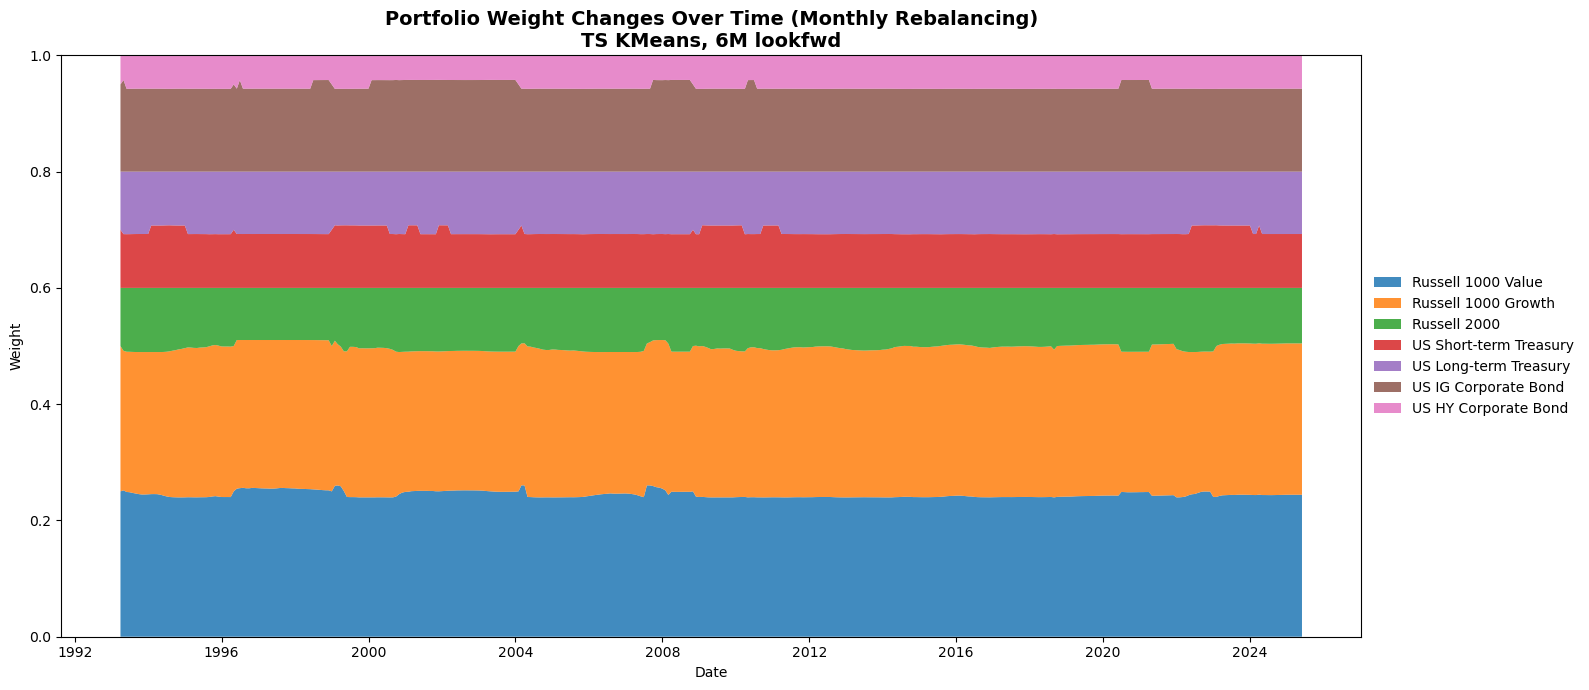

In [309]:
# ============================================================
# 13. Visualization: Portfolio weights over time
# ============================================================
import matplotlib.pyplot as plt

# Use monthly weights for clarity in stacked view
w_plot = w_m.copy()

plt.figure(figsize=(16, 7))
plt.stackplot(
    w_plot.index,
    [w_plot[col] for col in alloc_cols],
    labels=alloc_cols,
    alpha=0.85
)

plt.title("Portfolio Weight Changes Over Time (Monthly Rebalancing)\nTS KMeans, 6M lookfwd", fontsize=14, weight="bold")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.ylim(0, 1)

# Legend on the right side
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.tight_layout()
plt.show()

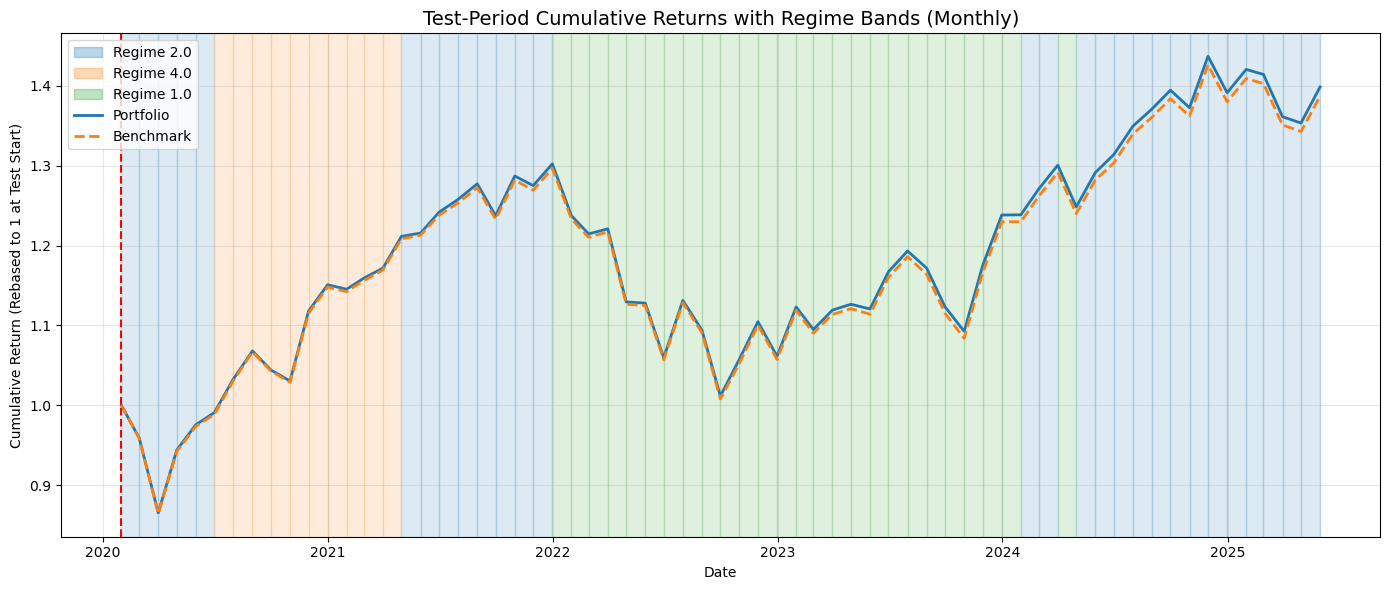

In [308]:
# ------------------------------------------------------------
# 1. Choose test start explicitly at Jan 2020 (month-end)
# ------------------------------------------------------------
test_start = pd.Timestamp("2020-01-31")

cum_port_full  = (1 + port_r_m).cumprod()
cum_bench_full = (1 + bench_r_m).cumprod()

cum_port  = cum_port_full.loc[cum_port_full.index  >= test_start].copy()
cum_bench = cum_bench_full.loc[cum_bench_full.index >= test_start].copy()

# Rebase to 1 at test start
cum_port  /= cum_port.iloc[0]
cum_bench /= cum_bench.iloc[0]

# ------------------------------------------------------------
# 2. Regime series (NO SHIFT VISUAL LAG)
# ------------------------------------------------------------
regime_col = "Regime_signal"   # still using shifted regime for decisions

regime_series = (
    df_regime[regime_col]
    .reindex(cum_port.index)   # 1-to-1 alignment to monthly test index
    .ffill()                   # fill any gaps
    .dropna()
)

# For monthly data regime index = monthly index, so no lag shows up visually
dates = regime_series.index
regs  = regime_series.values
unique_regs = list(pd.unique(regs))

colors = plt.cm.tab10.colors
reg_to_color_idx = {reg: i for i, reg in enumerate(unique_regs)}

# ------------------------------------------------------------
# 3. Plot the returns + bands
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.plot(cum_port.index,  cum_port.values,  label="Portfolio",  linewidth=2)
plt.plot(cum_bench.index, cum_bench.values, label="Benchmark", linewidth=2, linestyle="--")

# Regime bands: monthly contiguous bands
for i in range(len(dates)-1):
    reg = regs[i]
    s = dates[i]
    e = dates[i+1]
    cidx = reg_to_color_idx[reg]
    plt.axvspan(s, e, color=colors[cidx % len(colors)], alpha=0.15)

# Extend final band to last date
last_reg = regs[-1]
s_last = dates[-1]
e_last = cum_port.index[-1]
cidx_last = reg_to_color_idx[last_reg]
plt.axvspan(s_last, e_last, color=colors[cidx_last % len(colors)], alpha=0.15)

# Mark start of test period
plt.axvline(test_start, color="red", linestyle="--", linewidth=1.5)

plt.title("Test-Period Cumulative Returns with Regime Bands (Monthly)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Rebased to 1 at Test Start)")
plt.grid(alpha=0.3)

# Legend
regime_handles = [
    mpatches.Patch(
        color=colors[reg_to_color_idx[reg] % len(colors)],
        alpha=0.3,
        label=f"Regime {reg}"
    )
    for reg in unique_regs
]

line_handles, line_labels = plt.gca().get_legend_handles_labels()
plt.legend(
    regime_handles + line_handles,
    [h.get_label() for h in regime_handles] + line_labels,
    loc="upper left"
)

plt.tight_layout()
plt.show()

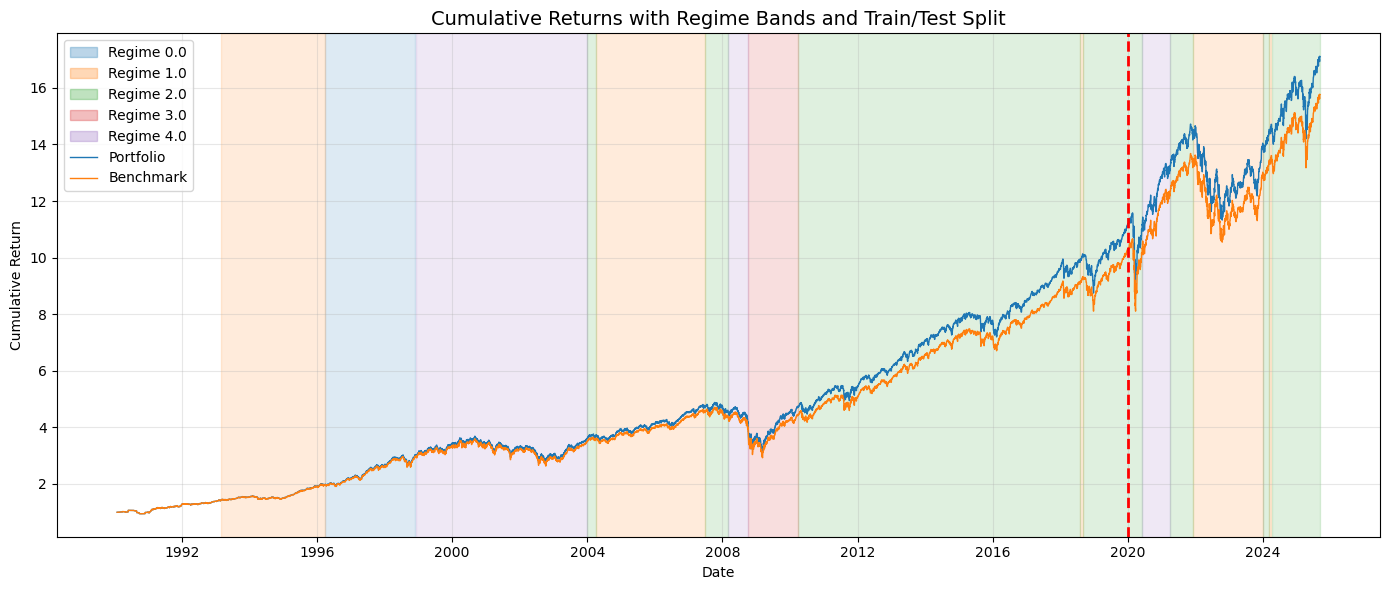

In [30]:
# ============================================================
# 13. Visualization: Regime bands with Train/Test Split (final clean version)
# ============================================================
# --- Choose which regime to show ---
regime_col = "Regime_signal"   # or "Regime_true" if you merged both
train_end = pd.Timestamp("2019-12-31")

# --- Compute cumulative returns ---
cum_port = (1 + port_r).cumprod()
cum_bench = (1 + bench_r).cumprod()

# --- Align regime timeline to return index ---
regime_series = df_regime[regime_col].reindex(cum_port.index, method="ffill")

# --- Normalize cumulative returns to start at 1 ---
cum_port /= cum_port.iloc[0]
cum_bench /= cum_bench.iloc[0]

# --- Create figure ---
plt.figure(figsize=(14, 6))

# --- Plot cumulative returns ---
plt.plot(cum_port, label="Portfolio", linewidth=1)
plt.plot(cum_bench, label="Benchmark", linewidth=1)

# --- Overlay color bands for regimes ---
unique_regs = sorted(regime_series.dropna().unique())
colors = plt.cm.tab10.colors

for i, reg in enumerate(unique_regs):
    mask = regime_series == reg
    starts = mask & ~mask.shift(1, fill_value=False)
    ends = mask & ~mask.shift(-1, fill_value=False)
    for s, e in zip(starts[starts].index, ends[ends].index):
        plt.axvspan(s, e, color=colors[i % len(colors)], alpha=0.15)

# --- Add red dashed line for Train/Test Split ---
plt.axvline(train_end, color="red", linestyle="--", linewidth=2)

# --- Titles and labels ---
plt.title(f"Cumulative Returns with Regime Bands and Train/Test Split", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

# --- Build legend with regime colors and lines ---
regime_handles = [
    mpatches.Patch(color=colors[i % len(colors)], alpha=0.3, label=f"Regime {reg}")
    for i, reg in enumerate(unique_regs)
]
line_handles, line_labels = plt.gca().get_legend_handles_labels()

plt.legend(
    regime_handles + line_handles,
    [h.get_label() for h in regime_handles] + line_labels,
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [270]:
# Expanding KMeans

# ---------------------------------
# 1. Standardize & build windows
# ---------------------------------
X_expanded = expanding_standardize(final_features, min_periods=24).dropna()
Xw, idx_w = make_windows(X_expanded, window=12)

# Ensure datetime index
if isinstance(idx_w, pd.PeriodIndex):
    idx_w_dt = idx_w.to_timestamp()
else:
    idx_w_dt = pd.to_datetime(idx_w)

In [271]:
final_k = 5
km_params = dict(
    n_clusters=final_k,
    metric="dtw",
    metric_params={"sakoe_chiba_radius": 1},
    n_init=3,
    max_iter=30,
    random_state=42,
)

# ---------------------------------------------------------
# Start KMeans regime assignment
# ---------------------------------------------------------
start_kmeans_date = pd.Timestamp("2005-01-01")

# Only use windows whose end date is >= start_kmeans_date
valid_mask = idx_w_dt >= start_kmeans_date
idx_w_dt_valid = idx_w_dt[valid_mask]
Xw_valid = Xw[valid_mask]

# # Year-end cutoffs from first valid year to last
# first_year = idx_w_dt_valid.min().year
# last_year = idx_w_dt_valid.max().year
# cutoffs = [
#     pd.Timestamp(year=y, month=12, day=31)
#     for y in range(first_year, last_year + 1)
# ]
# cutoffs = [c for c in cutoffs if c >= idx_w_dt_valid.min() and c <= idx_w_dt_valid.max()]

# ---------------------------------------------------------
# Semiannual cutoffs: Jun 30 and Dec 31 each year
# ---------------------------------------------------------
first_year = idx_w_dt_valid.min().year
last_year = idx_w_dt_valid.max().year

cutoffs = []
for y in range(first_year, last_year + 1):
    # June 30
    c1 = pd.Timestamp(year=y, month=6, day=30)
    # December 31
    c2 = pd.Timestamp(year=y, month=12, day=31)
    cutoffs.append(c1)
    cutoffs.append(c2)

# Keep only those cutoffs that fall within the available window dates
cutoffs = [c for c in cutoffs if idx_w_dt_valid.min() <= c <= idx_w_dt_valid.max()]
cutoffs = sorted(cutoffs)

# ---------------------------------------------------------
# Storage
# ---------------------------------------------------------
# Canonical regime labels over time (indexed by idx_w_dt_valid)
regime_canon = pd.Series(index=idx_w_dt_valid, dtype=float)

# Which refit (cutoff date) labeled each window (for debugging)
model_version = pd.Series(index=idx_w_dt_valid, dtype="datetime64[ns]")

# Canonical centroids (shape: k x window x n_features)
canonical_centroids = None

# Mapping history: for each cutoff, store new→canonical and canonical→new
mapping_history = {}

# NEW: diagnostic regimes at each cutoff
# Each entry: cutoff -> pd.Series(labels, index=idx_w_dt_valid[<= cutoff])
diagnostic_regimes = {}

prev_c = None
last_km = None
last_mapping_new_to_canon = None

for c in cutoffs:
    # Training windows: all valid windows up to cutoff c
    train_mask = idx_w_dt_valid <= c
    if train_mask.sum() < final_k:
        prev_c = c
        continue

    X_train = Xw_valid[train_mask]

    km = TimeSeriesKMeans(**km_params)
    km.fit(X_train)
    new_centroids = km.cluster_centers_     # shape (k, window, n_features)

    # Application range for canonical trading labels:
    # - For first cutoff: from earliest valid date up to c
    # - For later cutoffs: (prev_c, c]
    if prev_c is None:
        app_mask = (idx_w_dt_valid >= idx_w_dt_valid.min()) & (idx_w_dt_valid <= c)
    else:
        app_mask = (idx_w_dt_valid > prev_c) & (idx_w_dt_valid <= c)

    if app_mask.sum() == 0:
        prev_c = c
        continue

    X_app = Xw_valid[app_mask]
    raw_labels = km.predict(X_app)          # local labels {0,...,k-1}

    # -------------------------------
    # Centroid matching / label alignment
    # -------------------------------
    if canonical_centroids is None:
        # First model: its labels define canonical label space
        canonical_centroids = new_centroids.copy()
        mapped_labels = raw_labels.copy()

        new_to_canon = {int(j): int(j) for j in range(final_k)}
        canon_to_new = {int(j): int(j) for j in range(final_k)}
    else:
        # Compute DTW distances between canonical centroids and new centroids
        D = cdist_dtw(canonical_centroids, new_centroids)  # shape (k, k)

        # Hungarian algorithm: match canonical i <- new j
        row_ind, col_ind = linear_sum_assignment(D)

        new_to_canon = {}
        canon_to_new = {}
        for canon_idx, new_idx in zip(row_ind, col_ind):
            canon_idx = int(canon_idx)
            new_idx = int(new_idx)
            new_to_canon[new_idx] = canon_idx
            canon_to_new[canon_idx] = new_idx

        # Map raw labels in this application range to canonical label space
        mapped_labels = np.array([new_to_canon[int(l)] for l in raw_labels])

        # Update canonical centroids to this model's centroids, reordered
        canonical_centroids = np.zeros_like(new_centroids)
        for new_idx, canon_idx in new_to_canon.items():
            canonical_centroids[canon_idx] = new_centroids[new_idx]

    # Record mapping for this cutoff
    mapping_history[c] = {
        "new_to_canon": new_to_canon,
        "canon_to_new": canon_to_new,
    }

    # Store canonical labels and model version (trading path)
    regime_canon.loc[app_mask] = mapped_labels
    model_version.loc[app_mask] = c

    # -------------------------------
    # NEW: build diagnostic regimes at this cutoff
    # -------------------------------
    # For diagnostics, this same model km is applied to ALL history up to c,
    # and the raw labels are mapped into canonical space via new_to_canon.
    hist_mask = idx_w_dt_valid <= c
    X_hist = Xw_valid[hist_mask]
    raw_hist = km.predict(X_hist)
    mapped_hist = np.array([new_to_canon[int(l)] for l in raw_hist])

    diagnostic_regimes[c] = pd.Series(
        mapped_hist,
        index=idx_w_dt_valid[hist_mask],
        dtype=int
    )

    prev_c = c
    last_km = km
    last_mapping_new_to_canon = new_to_canon

# ---------------------------------------------------------
# After last cutoff: label any remaining windows with last model (canonical only)
# ---------------------------------------------------------
if (last_km is not None) and (last_mapping_new_to_canon is not None):
    tail_mask = idx_w_dt_valid > cutoffs[-1]
    if tail_mask.sum() > 0:
        X_tail = Xw_valid[tail_mask]
        raw_tail = last_km.predict(X_tail)
        mapped_tail = np.array([last_mapping_new_to_canon[int(l)] for l in raw_tail])

        regime_canon.loc[tail_mask] = mapped_tail
        model_version.loc[tail_mask] = cutoffs[-1]

# Final canonical regime dataframe (used for TRADING)
regime_df = (
    pd.DataFrame({"Regime": regime_canon})
    .dropna()
    .astype(int)
    .sort_index()
)

print("First 10 canonical regimes:")
print(regime_df.head(10))
print("\nLast 10 canonical regimes:")
print(regime_df.tail(10))

print("\nAvailable diagnostic cutoffs:")
print(list(diagnostic_regimes.keys())[:5], " ...")

First 10 canonical regimes:
            Regime
Date              
2005-01-01       2
2005-02-01       4
2005-03-01       0
2005-04-01       0
2005-05-01       3
2005-06-01       1
2005-07-01       1
2005-08-01       1
2005-09-01       3
2005-10-01       2

Last 10 canonical regimes:
            Regime
Date              
2024-07-01       0
2024-08-01       0
2024-09-01       0
2024-10-01       0
2024-11-01       0
2024-12-01       0
2025-01-01       0
2025-02-01       0
2025-03-01       0
2025-04-01       0

Available diagnostic cutoffs:
[Timestamp('2005-06-30 00:00:00'), Timestamp('2005-12-31 00:00:00'), Timestamp('2006-06-30 00:00:00'), Timestamp('2006-12-31 00:00:00'), Timestamp('2007-06-30 00:00:00')]  ...


In [272]:
# Build daily diagnostic regime series for each cutoff
df_regime_diag = {}  # cutoff -> daily df with "Regime"

for c, s in diagnostic_regimes.items():
    # s: Series of regimes indexed by monthly window-end dates <= c
    reg_monthly = s.to_frame("Regime").copy()
    reg_monthly.index = pd.to_datetime(reg_monthly.index)

    tmp = (
        pd.merge_asof(
            df_px.reset_index(),  # daily prices
            reg_monthly.reset_index().rename(columns={reg_monthly.index.name or "index": "Regime_Date"}),
            left_on="Date",
            right_on="Regime_Date",
            direction="backward"
        )
        .set_index("Date")
        .drop(columns=["Regime_Date"])
        .ffill()
    )

    df_regime_diag[c] = tmp

cutoffs_sorted = sorted(df_regime_diag.keys())
print("Diagnostic cutoffs used for allocation:", cutoffs_sorted)

Diagnostic cutoffs used for allocation: [Timestamp('2005-06-30 00:00:00'), Timestamp('2005-12-31 00:00:00'), Timestamp('2006-06-30 00:00:00'), Timestamp('2006-12-31 00:00:00'), Timestamp('2007-06-30 00:00:00'), Timestamp('2007-12-31 00:00:00'), Timestamp('2008-06-30 00:00:00'), Timestamp('2008-12-31 00:00:00'), Timestamp('2009-06-30 00:00:00'), Timestamp('2009-12-31 00:00:00'), Timestamp('2010-06-30 00:00:00'), Timestamp('2010-12-31 00:00:00'), Timestamp('2011-06-30 00:00:00'), Timestamp('2011-12-31 00:00:00'), Timestamp('2012-06-30 00:00:00'), Timestamp('2012-12-31 00:00:00'), Timestamp('2013-06-30 00:00:00'), Timestamp('2013-12-31 00:00:00'), Timestamp('2014-06-30 00:00:00'), Timestamp('2014-12-31 00:00:00'), Timestamp('2015-06-30 00:00:00'), Timestamp('2015-12-31 00:00:00'), Timestamp('2016-06-30 00:00:00'), Timestamp('2016-12-31 00:00:00'), Timestamp('2017-06-30 00:00:00'), Timestamp('2017-12-31 00:00:00'), Timestamp('2018-06-30 00:00:00'), Timestamp('2018-12-31 00:00:00'), Timesta

In [181]:
def plot_regime_snapshot(regime_df, end_date, k=final_k, title_suffix=""):
    """
    Plot the canonical (centroid-matched) regimes used by the trading model,
    from the start up to the given end_date.
    """
    sub = regime_df.loc[:end_date].copy()
    if sub.empty:
        print(f"No regimes available up to {end_date}.")
        return
    
    x = sub.index
    vals = sub["Regime"].values
    unique_regs = sorted(sub["Regime"].dropna().unique())
    palette = sns.color_palette("Set2", n_colors=len(unique_regs))
    colors = dict(zip(unique_regs, palette))

    seg_starts = [x[0]]
    seg_labels = [vals[0]]
    for i in range(1, len(vals)):
        if vals[i] != vals[i - 1]:
            seg_starts.append(x[i])
            seg_labels.append(vals[i])
    seg_ends = seg_starts[1:] + [x[-1]]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.step(x, vals, where="post", color="black", lw=1.3)

    for s, e, lab in zip(seg_starts, seg_ends, seg_labels):
        ax.axvspan(s, e, color=colors.get(lab, "grey"), alpha=0.25)

    handles = [mpatches.Patch(color=colors[r], label=f"Regime {r}") for r in unique_regs]
    ax.legend(handles=handles, title="Regime", loc="upper left")

    ax.set_title(f"Canonical Regimes up to {end_date.date()} (k={k}) {title_suffix}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Regime ID")
    ax.grid(alpha=0.3)

    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    plt.show()

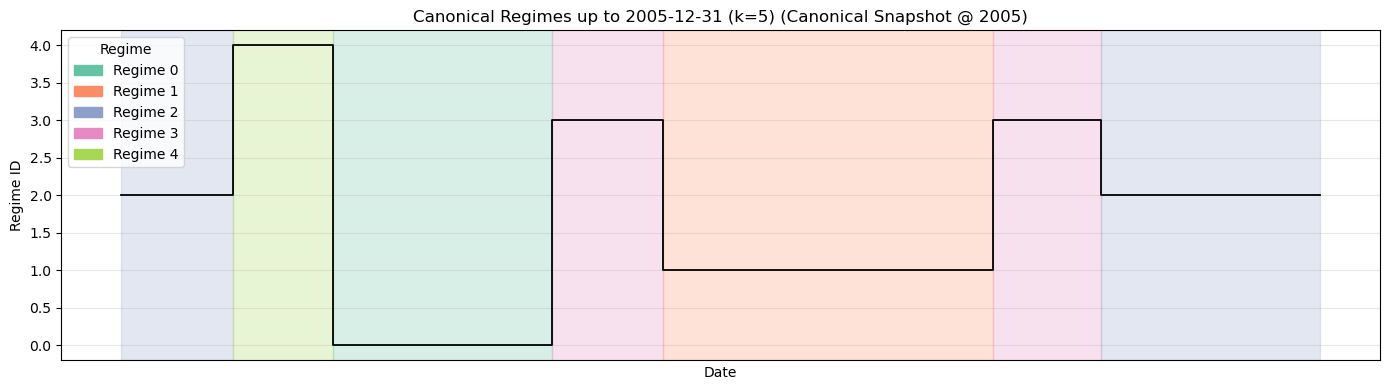

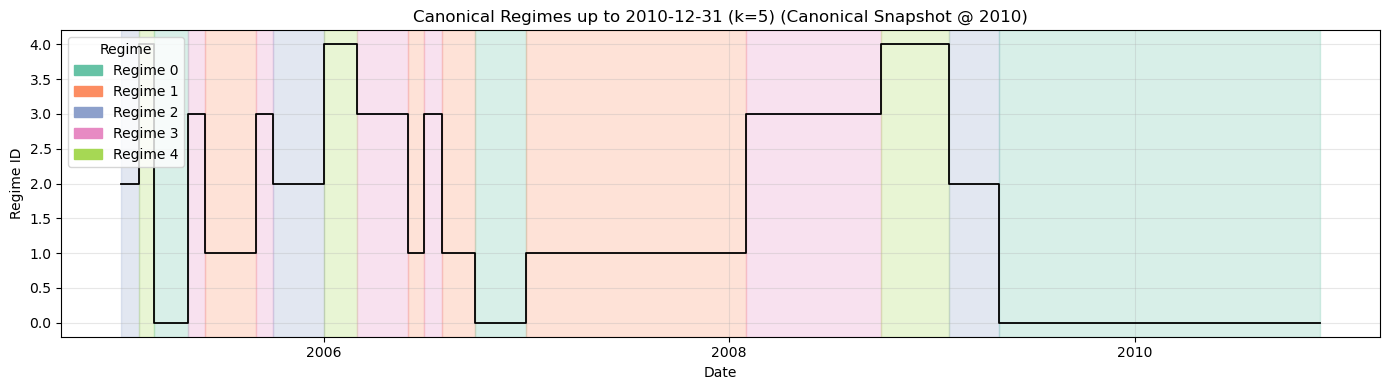

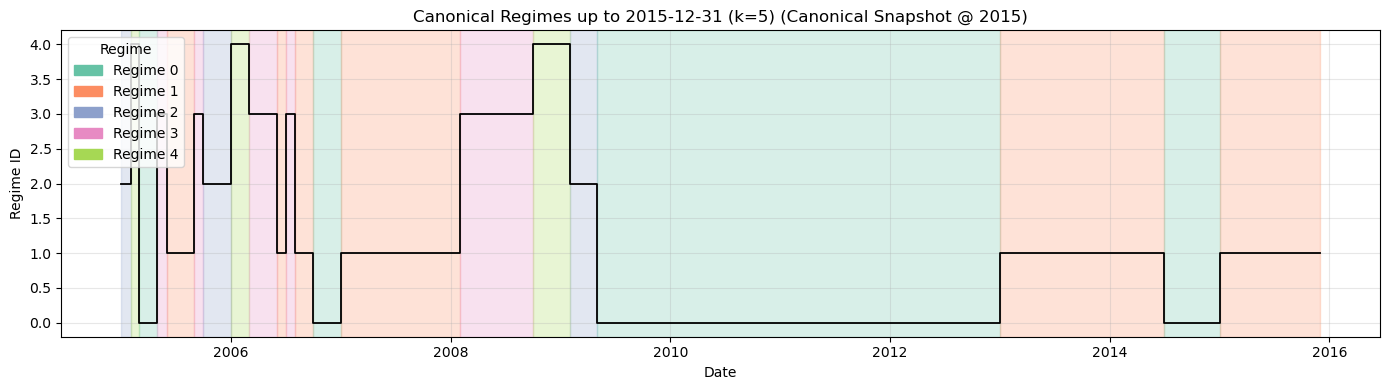

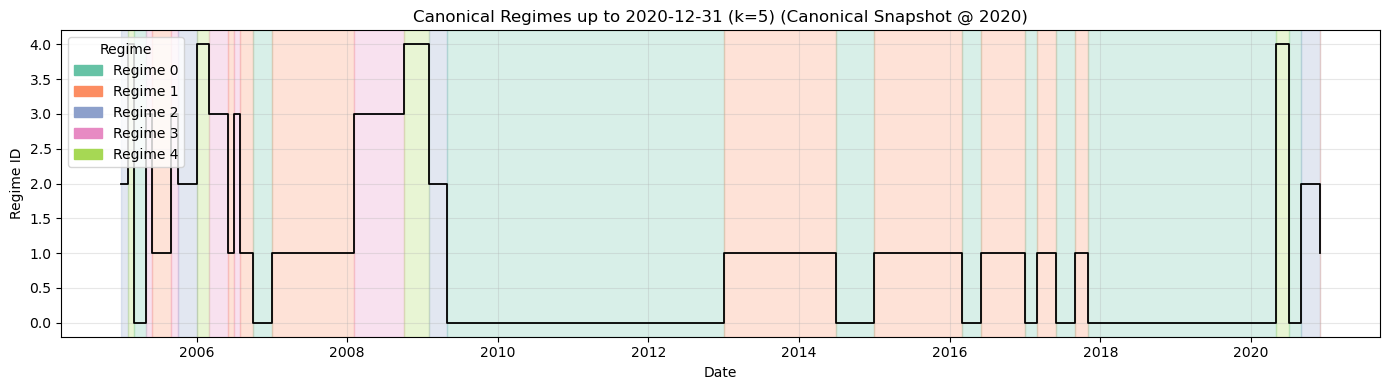

In [182]:
snapshot_dates = [
    pd.Timestamp("2005-12-31"),
    pd.Timestamp("2010-12-31"),
    pd.Timestamp("2015-12-31"),
    pd.Timestamp("2020-12-31"),
    pd.Timestamp("2025-12-31"),
]

for d in snapshot_dates:
    if d <= regime_df.index.max():
        plot_regime_snapshot(
            regime_df,
            d,
            k=final_k,
            title_suffix=f"(Canonical Snapshot @ {d.year})"
        )

In [183]:
def plot_regime_snapshot_diagnostic(diagnostic_regimes, cutoff, k=final_k, title_suffix=""):
    """
    Plot diagnostic regimes:
    - A model trained at 'cutoff' is applied to ALL history up to that cutoff,
      with labels mapped into canonical space.
    """
    cutoff = pd.Timestamp(cutoff)
    if cutoff not in diagnostic_regimes:
        print(f"No diagnostic regimes stored for cutoff {cutoff}.")
        return
    
    s = diagnostic_regimes[cutoff]
    regime_df_snap = pd.DataFrame({"Regime": s}).sort_index()

    # Use the same plotting logic, but with a different title
    sub = regime_df_snap.copy()
    x = sub.index
    vals = sub["Regime"].values
    unique_regs = sorted(sub["Regime"].dropna().unique())
    palette = sns.color_palette("Set2", n_colors=len(unique_regs))
    colors = dict(zip(unique_regs, palette))

    seg_starts = [x[0]]
    seg_labels = [vals[0]]
    for i in range(1, len(vals)):
        if vals[i] != vals[i - 1]:
            seg_starts.append(x[i])
            seg_labels.append(vals[i])
    seg_ends = seg_starts[1:] + [x[-1]]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.step(x, vals, where="post", color="black", lw=1.3)

    for s_, e, lab in zip(seg_starts, seg_ends, seg_labels):
        ax.axvspan(s_, e, color=colors.get(lab, "grey"), alpha=0.25)

    handles = [mpatches.Patch(color=colors[r], label=f"Regime {r}") for r in unique_regs]
    ax.legend(handles=handles, title="Regime", loc="upper left")

    ax.set_title(
        f"Diagnostic Regimes (Model trained up to {cutoff.date()}) (k={k}) {title_suffix}"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Regime ID")
    ax.grid(alpha=0.3)

    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    plt.show()

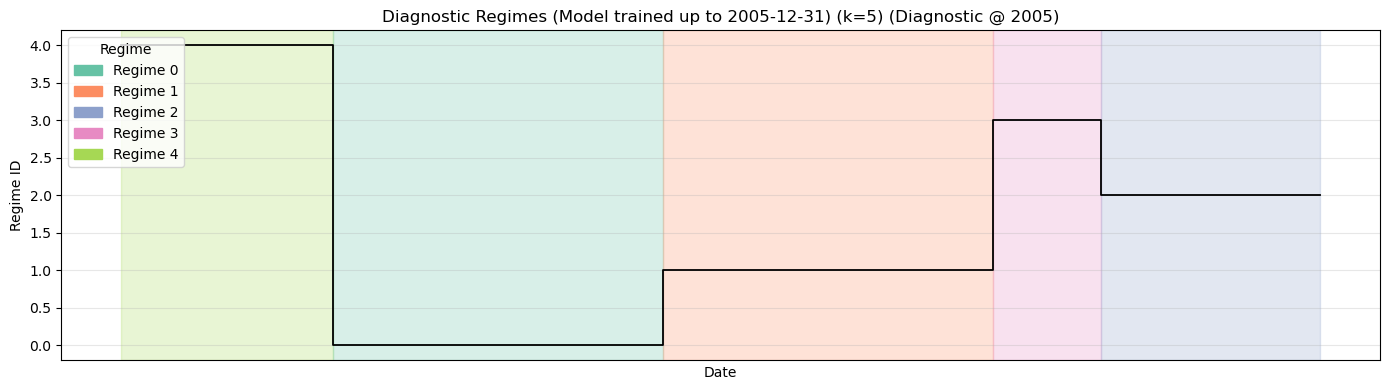

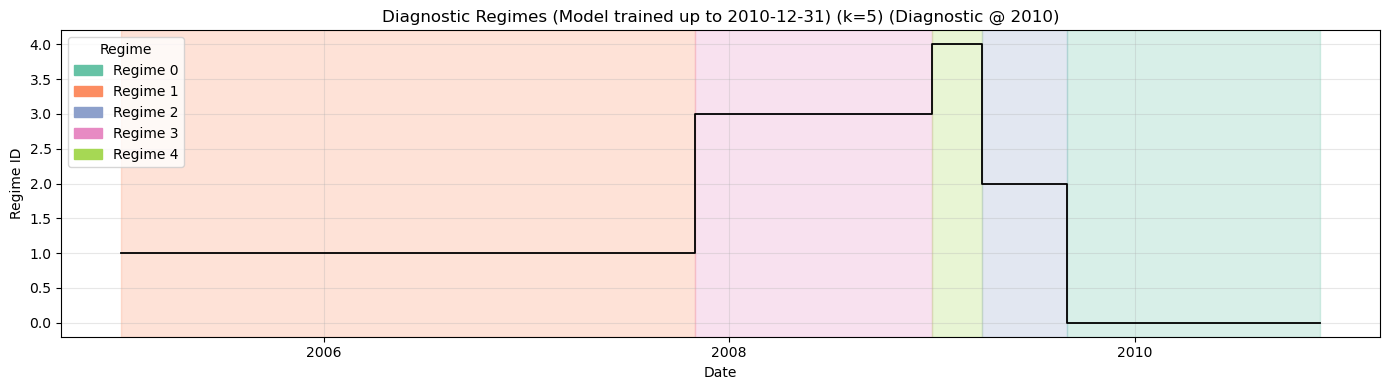

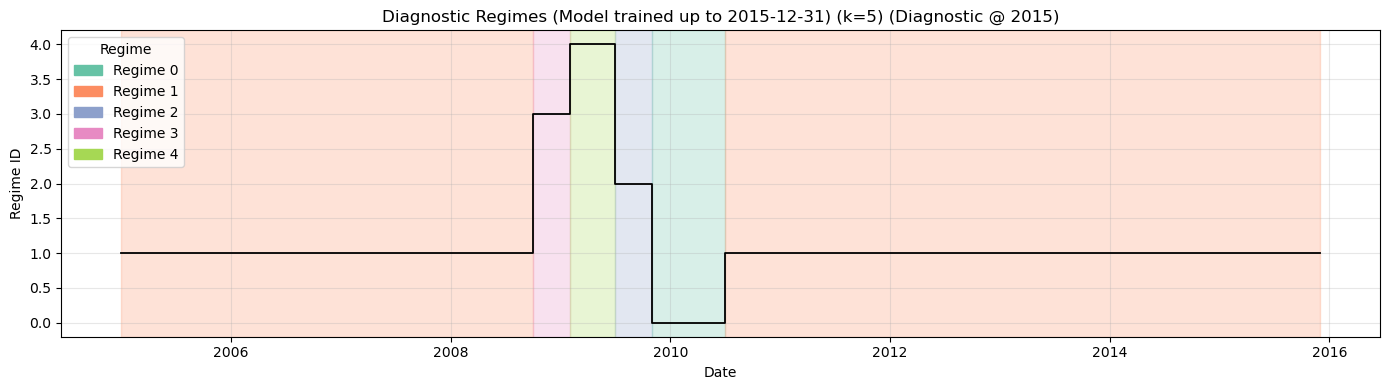

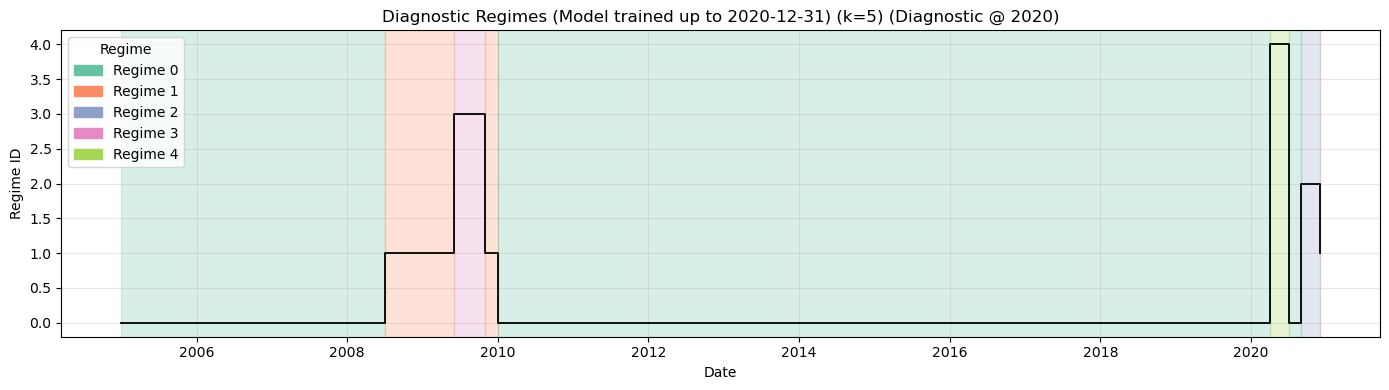

In [184]:
for d in snapshot_dates:
    # only where we actually trained a model
    if d in diagnostic_regimes:
        plot_regime_snapshot_diagnostic(
            diagnostic_regimes,
            cutoff=d,
            k=final_k,
            title_suffix=f"(Diagnostic @ {d.year})"
        )

In [135]:
sf_df = pd.read_csv('core_features.csv', index_col=0)
sf_df

,INDPRO,CUSR0000SAS,USGG2YR Index,LUACOAS Index,VIX Index,CAPE,.MARGINSP G Index,USURTOT Index,SPX Index
Date,,,,,,,,,
1990-04-01,-0.002251,-0.001489,0.3220,0.91,19.52,-0.019834,NaN,5.2,339.9400
1990-05-01,0.002950,-0.000744,-0.4620,0.87,17.37,0.578500,NaN,5.4,330.8000
1990-06-01,0.003394,0.002873,-0.2620,0.88,15.50,0.424669,NaN,5.4,361.2300
1990-07-01,-0.001665,-0.000758,-0.3410,0.91,21.11,-0.069911,NaN,5.2,358.0200
1990-08-01,0.003616,0.001391,0.1840,0.94,29.90,-1.578837,NaN,5.5,356.1500
...,...,...,...,...,...,...,...,...,...
2024-12-01,0.010677,0.000146,0.0907,0.80,17.35,0.360996,12.2346,4.2,6032.3799
2025-01-01,-0.001595,0.002170,-0.0445,0.79,16.43,-0.581972,12.2395,4.1,5881.6299
2025-02-01,0.009577,-0.001970,-0.2082,0.87,19.63,0.057956,12.2347,4.0,6040.5298


In [90]:
def summarize_features_by_regime(selected_features, regime_df, 
                                 scale_col1=100, scale_col2=1000,
                                 tolerance_days=60, plot=True):

    # ============================================================
    # 0. Preprocess regime_df to standard format
    # ============================================================
    if isinstance(regime_df, pd.Series):
        regime_df = regime_df.to_frame(name="Regime")

    if "Regime" not in regime_df.columns:
        possible_cols = [c for c in regime_df.columns if c.lower() != "date"]
        if len(possible_cols) != 1:
            raise ValueError("regime_df must contain a single regime column.")
        regime_df = regime_df.rename(columns={possible_cols[0]: "Regime"})

    if not isinstance(regime_df.index, pd.DatetimeIndex):
        if "Date" in regime_df.columns:
            regime_df["Date"] = pd.to_datetime(regime_df["Date"])
            regime_df = regime_df.set_index("Date")
        else:
            regime_df.index = pd.to_datetime(regime_df.index)

    # sort
    regime_df = regime_df.sort_index()

    # ============================================================
    # 1. merge_asof alignment
    # ============================================================

    sf = selected_features.sort_index().copy()
    rg = regime_df.sort_index().copy()

    sf = sf.reset_index().rename(columns={"index": "Date"})
    rg = rg.reset_index().rename(columns={"index": "Date"})
    sf['Date'] = pd.to_datetime(sf['Date'])

    merged = pd.merge_asof(
        sf, rg,
        on="Date",
        direction="nearest",
        tolerance=pd.Timedelta(f"{tolerance_days}D")
    )

    merged = merged.dropna(subset=["Regime"])
    merged["Regime"] = merged["Regime"].astype(int)
    merged = merged.set_index("Date")

    feature_cols = selected_features.columns.tolist()

    # ============================================================
    # 2. Scaling
    # ============================================================

    scaled_data = merged.copy()

    scale_factor = {col: 1 for col in feature_cols}
    col1, col2 = feature_cols[0], feature_cols[1]

    scaled_data[col1] *= scale_col1
    scaled_data[col2] *= scale_col2

    scale_factor[col1] = scale_col1
    scale_factor[col2] = scale_col2

    print("\n===== Scale Factors Applied =====")
    print(scale_factor)

    # ============================================================
    # 3. Mean ± Std
    # ============================================================

    mean_tbl = scaled_data.groupby("Regime")[feature_cols].mean()
    std_tbl = scaled_data.groupby("Regime")[feature_cols].std()

    # label columns with scaling info
    new_colnames = []
    for col in feature_cols:
        if scale_factor[col] != 1:
            new_colnames.append(f"{col} (×{scale_factor[col]})")
        else:
            new_colnames.append(f"{col} (×1)")

    mean_tbl.columns = new_colnames
    std_tbl.columns = new_colnames

    summary_tbl = (
        mean_tbl.round(2).astype(str)
        + " ± "
        + std_tbl.round(2).astype(str)
    )

    print("\n===== Feature Distribution by Regime (Mean ± Std) =====")
    print(summary_tbl)

    # ============================================================
    # 4. Heatmap
    # ============================================================

    if plot:
        mean_values = mean_tbl.T.copy()

        mean_row_scaled = (mean_values - mean_values.min(axis=1).values[:, None]) / \
                          (mean_values.max(axis=1).values[:, None] - mean_values.min(axis=1).values[:, None] + 1e-12)

        plt.figure(figsize=(14, 7))

        sns.heatmap(
            mean_row_scaled,
            annot=mean_values.round(2),
            fmt=".2f",
            cmap="YlGn",
            cbar=True
        )

        plt.title("Feature Means by Regime (Row-Normalized)")
        plt.xlabel("Regime")
        plt.ylabel("Indicator")
        plt.tight_layout()
        plt.show()

    return summary_tbl, mean_tbl, std_tbl

regime_df_2010 = diagnostic_regimes[pd.Timestamp("2010-12-31")]
regime_df_2015 = diagnostic_regimes[pd.Timestamp("2015-12-31")]
regime_df_2020 = diagnostic_regimes[pd.Timestamp("2020-12-31")]

In [87]:
regime_df_2010

Date
2005-01-01    1
2005-02-01    1
2005-03-01    1
2005-04-01    1
2005-05-01    1
             ..
2010-08-01    0
2010-09-01    0
2010-10-01    0
2010-11-01    0
2010-12-01    0
Length: 72, dtype: int64

In [ ]:
summarize_features_by_regime(sf_df, regime_df_2010)

In [ ]:
summarize_features_by_regime(sf_df, regime_df_2015)

In [ ]:
summarize_features_by_regime(sf_df, regime_df_2020)

In [273]:
# ============================================================
# Make expanding diagnostic regimes monthly
# ============================================================
df_regime_diag_m = {}
for c, df_c in df_regime_diag.items():
    tmp = df_c.copy()
    # tmp can be a DataFrame with "Regime" column or a Series
    if isinstance(tmp, pd.DataFrame):
        if "Regime" in tmp.columns:
            ser = tmp["Regime"]
        else:
            # assume first column is the regime label
            ser = tmp.iloc[:, 0]
    else:
        ser = tmp  # Series

    # Resample to month-end and keep last non-NA regime in month
    ser_m = ser.resample("M").last().dropna()
    df_regime_diag_m[c] = ser_m.to_frame("Regime")

/var/folders/n6/pz2q030s2892kgbyw470z2nm0000gn/T/ipykernel_73996/474458376.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ser_m = ser.resample("M").last().dropna()


In [274]:
# ============================================================
# Forward 6-month returns (monthly)
# ============================================================
fwd6m = px_m.shift(-6) / px_m - 1.0
fwd6m = fwd6m.dropna(how="all")

In [275]:
# ============================================================
# Past regime stats using expanding history (no look-ahead)
# ============================================================
def active_cutoff_for_date(t, cutoffs_sorted):
    """Return the latest expanding-KMeans cutoff <= t."""
    t = pd.Timestamp(t)
    eligible = [c for c in cutoffs_sorted if c <= t]
    if not eligible:
        return None
    return eligible[-1]

def past_regime_stats(decision_date):
    """
    Use diagnostic regimes from the last refit (cutoff <= decision_date).
    Use only past samples whose forward 6-month windows end before decision_date.
    """
    decision_date = pd.Timestamp(decision_date)

    # 1) Which diagnostic model is active?
    c_curr = active_cutoff_for_date(decision_date, cutoffs_sorted)
    if c_curr is None:
        return pd.DataFrame(), pd.DataFrame()

    df_regime_c = df_regime_diag_m[c_curr]          # monthly regimes
    reg_series = df_regime_c["Regime"].reindex(fwd6m.index)

    # 2) Restrict forward-6m samples to windows that end before decision_date
    valid_idx = fwd6m.index < decision_date

    df_tmp = fwd6m.loc[valid_idx].copy()
    df_tmp["regime"] = reg_series.loc[valid_idx].values
    df_tmp = df_tmp.dropna(subset=["regime"])

    means = df_tmp.groupby("regime")[alloc_cols].mean()
    counts = df_tmp.groupby("regime")[alloc_cols].count()
    return means, counts

def shrink_table(means, counts, ridge=0.02):
    gmean = means.stack().mean()
    w = counts / (counts + ridge * counts.stack().mean())
    return w * means + (1 - w) * gmean

In [276]:
# ============================================================
# Target weights mapping from signals (monthly)
# ============================================================
def target_from_signals(mu):
    sig = pd.Series(0.0, index=alloc_cols)
    for g, names in groups.items():
        m = mu[names].dropna()
        if len(m) >= 2:
            z = (m - m.mean()) / (m.std(ddof=0) + 1e-8)
            sig.loc[m.index] = z

    # Map standardized signals to target tilts around the benchmark
    w_des = bench + 0.05 * sig / (sig.abs().sum() + 1e-8)

    n = len(alloc_cols)
    w = cp.Variable(n)
    Aeq = np.ones((1, n))
    beq = np.array([1.0])
    constraints = [w >= 0, Aeq @ w == beq]

    # ±5% per asset
    for i, name in enumerate(alloc_cols):
        constraints += [w[i] >= bench[name] - 0.05,
                        w[i] <= bench[name] + 0.05]

    # ±10% per group
    for g, names in groups.items():
        idx = [alloc_cols.index(nm) for nm in names]
        constraints += [
            cp.sum(w[idx]) >= group_totals(bench)[g] - 0.10,
            cp.sum(w[idx]) <= group_totals(bench)[g] + 0.10,
        ]

    obj = cp.Minimize(cp.sum_squares(w - w_des.values))
    cp.Problem(obj, constraints).solve(solver=cp.ECOS, verbose=False)
    w_opt = np.maximum(0, w.value)
    return pd.Series(w_opt / w_opt.sum(), index=alloc_cols)

# ============================================================
# Monthly rebalancing with expanding TS-KMeans regimes
# ============================================================
month_starts = ret_m.index
weights_m = {}

for m_start in month_starts:
    m_start = pd.Timestamp(m_start)

    # Which expanding-KMeans cutoff is active?
    c_curr = active_cutoff_for_date(m_start, cutoffs_sorted)
    if c_curr is None:
        weights_m[m_start] = bench.copy()
        continue

    df_regime_c = df_regime_diag_m[c_curr]   # monthly regimes for this model

    if m_start not in df_regime_c.index:
        weights_m[m_start] = bench.copy()
        continue

    reg = df_regime_c.loc[m_start, "Regime"]

    if pd.isna(reg):
        weights_m[m_start] = bench.copy()
        continue

    means, counts = past_regime_stats(m_start)
    if reg not in means.index:
        weights_m[m_start] = bench.copy()
        continue

    mu_reg = shrink_table(means, counts).loc[reg].reindex(alloc_cols)
    w_t = target_from_signals(mu_reg.fillna(0))
    weights_m[m_start] = w_t

w_m = pd.DataFrame(weights_m).T.sort_index()

In [277]:
# ============================================================
# Portfolio & benchmark monthly returns (expanding regimes)
# ============================================================
port_r_m = (w_m * ret_m[alloc_cols]).sum(axis=1)

bench_w_m = pd.DataFrame(
    [bench.reindex(alloc_cols).values] * len(ret_m),
    index=ret_m.index,
    columns=alloc_cols,
)
bench_r_m = (bench_w_m * ret_m[alloc_cols]).sum(axis=1)
excess_r_m = port_r_m - bench_r_m

# ============================================================
# Performance evaluation (monthly)
# ============================================================
ann_factor = 12

def perf_stats(returns):
    cum = (1 + returns).cumprod()
    roll_max = cum.cummax()
    drawdown = 1 - cum / roll_max
    return pd.Series({
        "Annualized Return": returns.mean() * ann_factor,
        "Volatility (Ann)":  returns.std() * np.sqrt(ann_factor),
        "Sharpe Ratio":      (returns.mean() / returns.std()) * np.sqrt(ann_factor)
                             if returns.std() > 0 else np.nan,
        "Max Drawdown":      drawdown.max(),
    })

def excess_stats(port, bench):
    excess = port - bench
    te = excess.std() * np.sqrt(ann_factor)
    ir = excess.mean() * ann_factor / te if te > 0 else np.nan
    return pd.Series({
        "Excess Return (Ann)": excess.mean() * ann_factor,
        "Tracking Error (Ann)": te,
        "Information Ratio":    ir,
    })

eval_start = pd.Timestamp("2005-01-31")  # or whatever you use
eval_start = max(
    eval_start,
    w_m.index.min() if not w_m.empty else eval_start,
    port_r_m.index.min()
)

port_eval  = port_r_m.loc[port_r_m.index >= eval_start]
bench_eval = bench_r_m.loc[bench_r_m.index >= eval_start]

eval_port  = perf_stats(port_eval)
eval_bench = perf_stats(bench_eval)
eval_ex    = excess_stats(port_eval, bench_eval)

summary_eval = pd.concat([
    eval_port.rename("Portfolio"),
    eval_bench.rename("Benchmark"),
    eval_ex.rename("Excess")
], axis=1)

percent_metrics = [
    "Annualized Return", "Volatility (Ann)",
    "Excess Return (Ann)", "Tracking Error (Ann)", "Max Drawdown"
]

def fmt_val(x, is_pct):
    if pd.isna(x):
        return "—"
    return f"{x*100:.2f}%" if is_pct else f"{x:.2f}"

for m in summary_eval.index:
    summary_eval.loc[m] = [
        fmt_val(v, m in percent_metrics)
        for v in summary_eval.loc[m]
    ]

print(f"Performance from {eval_start.date()} onward (Expanding TS-KMeans RABT, monthly):")
display(summary_eval)

Performance from 2005-01-31 onward (Expanding TS-KMeans RABT, monthly):


/var/folders/n6/pz2q030s2892kgbyw470z2nm0000gn/T/ipykernel_73996/431534541.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.27%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_eval.loc[m] = [
/var/folders/n6/pz2q030s2892kgbyw470z2nm0000gn/T/ipykernel_73996/431534541.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.09%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_eval.loc[m] = [
/var/folders/n6/pz2q030s2892kgbyw470z2nm0000gn/T/ipykernel_73996/431534541.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '—' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_eval.loc[m] = [


,Portfolio,Benchmark,Excess
Annualized Return,7.27%,7.09%,—
Volatility (Ann),10.35%,10.34%,—
Sharpe Ratio,0.70,0.69,—
Max Drawdown,34.84%,35.28%,—
Excess Return (Ann),—,—,0.18%
Tracking Error (Ann),—,—,0.13%
Information Ratio,—,—,1.40


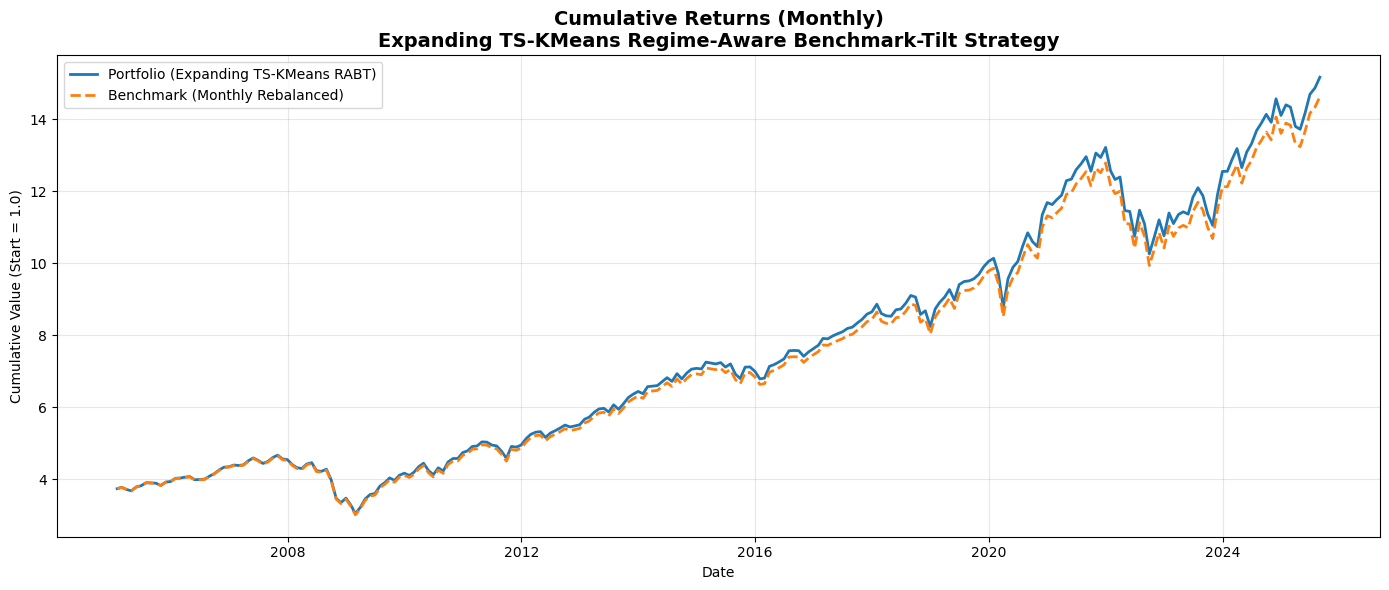

In [279]:
# ============================================================
# Cumulative Returns Plot (Monthly Expanding TS-KMeans RABT)
# ============================================================
plt.figure(figsize=(14, 6))

cum_port = (1 + port_r_m).cumprod()
cum_bench = (1 + bench_r_m).cumprod()

# Restrict to evaluation period
cum_port_plot  = cum_port.loc[cum_port.index >= eval_start]
cum_bench_plot = cum_bench.loc[cum_bench.index >= eval_start]

plt.plot(
    cum_port_plot.index, 
    cum_port_plot.values, 
    label="Portfolio (Expanding TS-KMeans RABT)", 
    linewidth=2
)

plt.plot(
    cum_bench_plot.index, 
    cum_bench_plot.values, 
    label="Benchmark (Monthly Rebalanced)", 
    linewidth=2, 
    linestyle="--"
)

plt.title(
    "Cumulative Returns (Monthly)\nExpanding TS-KMeans Regime-Aware Benchmark-Tilt Strategy",
    fontsize=14, 
    weight="bold"
)
plt.xlabel("Date")
plt.ylabel("Cumulative Value (Start = 1.0)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

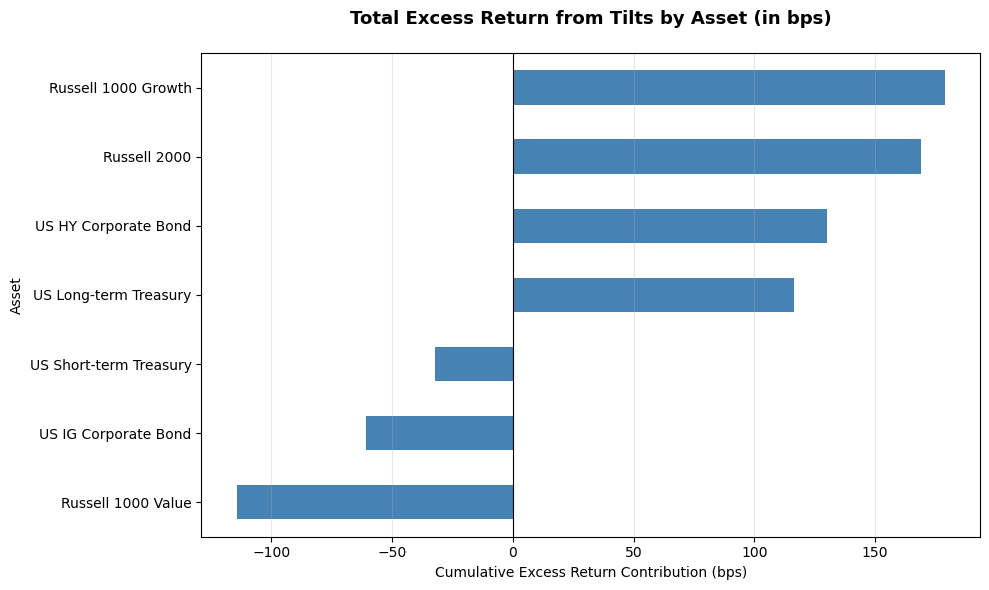

In [202]:
# Convert cumulative contribution to basis points (bps)
final_contrib_bps = final_contrib * 10000   # 1.0 → 10,000 bps

plt.figure(figsize=(10, 6))

final_contrib_bps.sort_values().plot(kind="barh", color="steelblue")

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Cumulative Excess Return Contribution (bps)")
plt.ylabel("Asset")
plt.title(
    f"Total Excess Return from Tilts by Asset (in bps)\n",
    fontsize=13,
    weight="bold"
)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

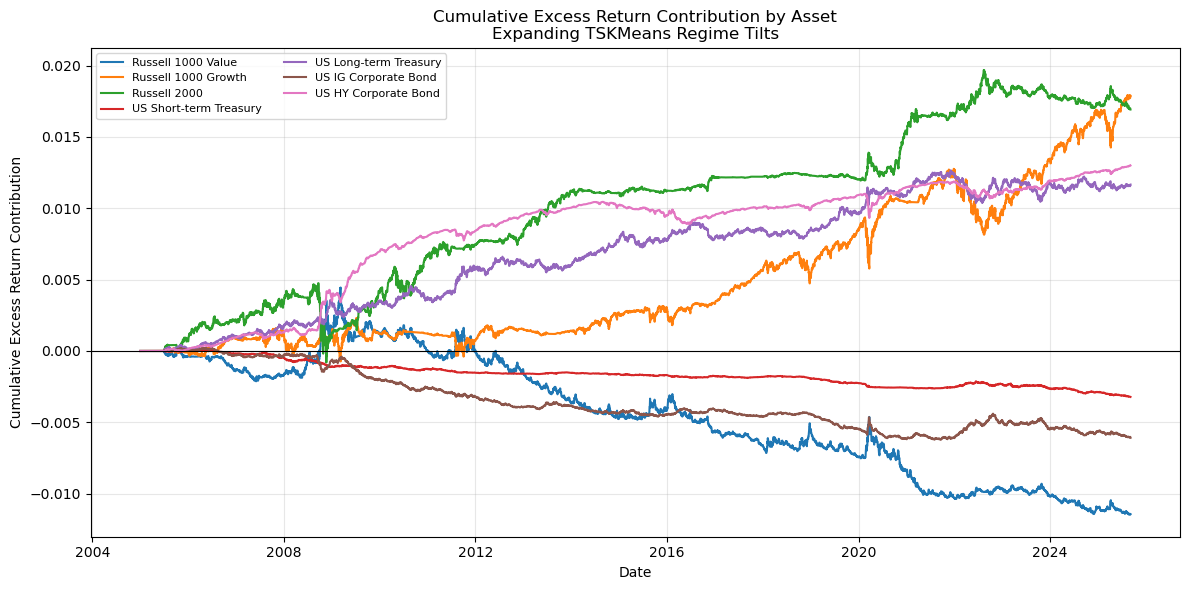

In [192]:
plt.figure(figsize=(12, 6))
for col in alloc_cols:
    plt.plot(cum_contrib.index, cum_contrib[col], label=col)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Cumulative Excess Return Contribution")
plt.xlabel("Date")
plt.title("Cumulative Excess Return Contribution by Asset\nExpanding TSKMeans Regime Tilts")
plt.legend(loc="upper left", ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

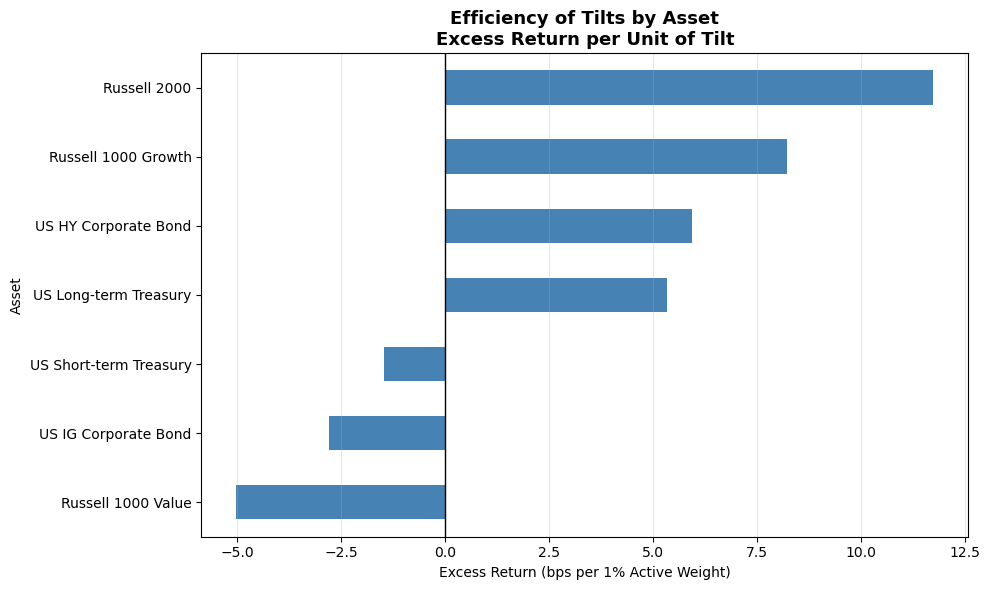

In [200]:
plt.figure(figsize=(10, 6))

efficiency_bps_per_pct.sort_values().plot(kind="barh", color="steelblue")

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Excess Return (bps per 1% Active Weight)")
plt.ylabel("Asset")
plt.title(
    "Efficiency of Tilts by Asset\n"
    f"Excess Return per Unit of Tilt",
    fontsize=13,
    weight="bold"
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

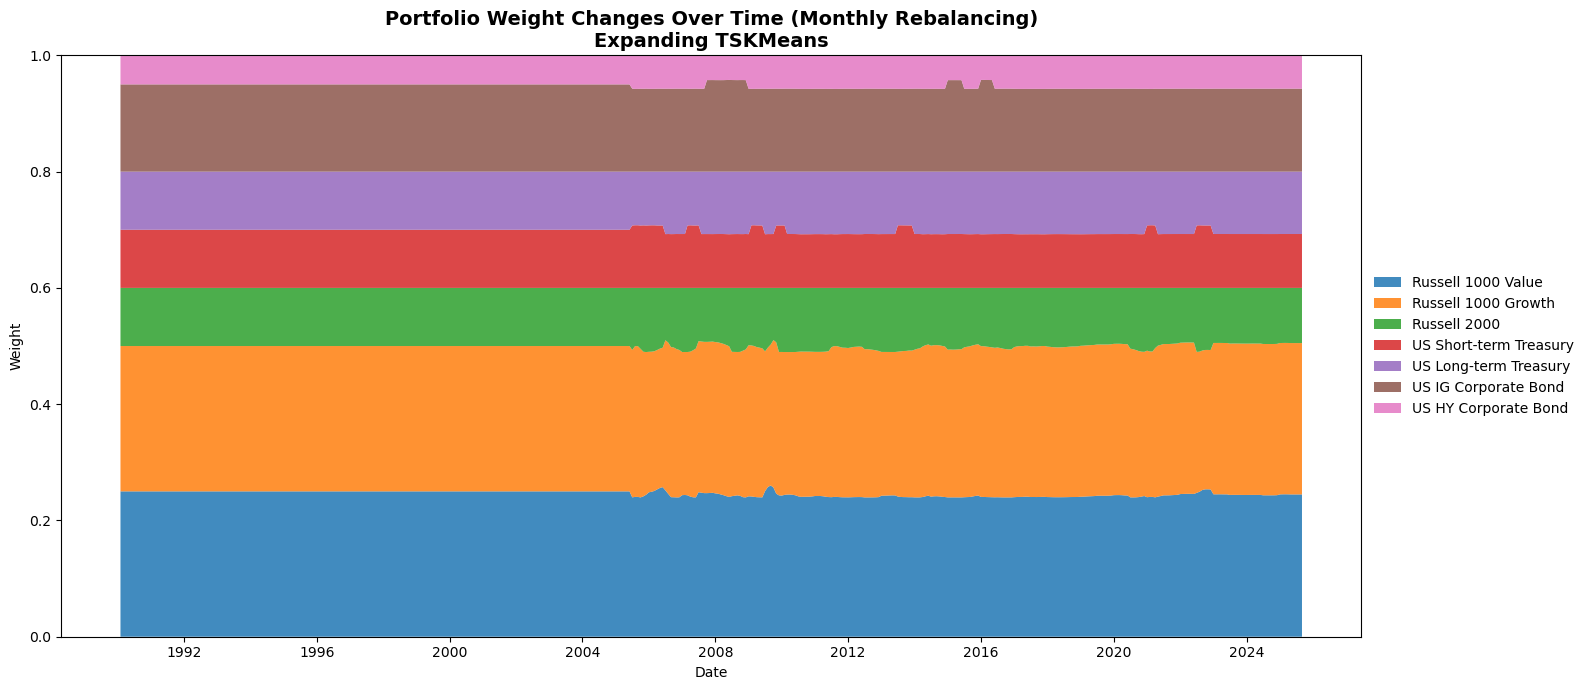

In [94]:
w_plot = w_m.copy()

plt.figure(figsize=(16, 7))
plt.stackplot(
    w_plot.index,
    [w_plot[col] for col in alloc_cols],
    labels=alloc_cols,
    alpha=0.85
)

plt.title(
    "Portfolio Weight Changes Over Time (Monthly Rebalancing)\nExpanding TSKMeans",
    fontsize=14,
    weight="bold"
)
plt.xlabel("Date")
plt.ylabel("Weight")
plt.ylim(0, 1)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.tight_layout()
plt.show()